# Top N Representative Scene Images

This notebook loads `outputs/hsi_scene_ranking.csv`, shows top **N** representative images, lets you click-select scenes, and exports them for transfer to another machine.

Workflow:
1. Run Cell 2 (imports + path setup).
2. Set parameters in Cell 3 and run it.
3. Run Cell 4 and click **Select** on scenes you want.
4. In Cell 4, copy the selected scene IDs text.
5. Paste that into Cell 5 (`SELECTED_IDS_TEXT`) and run Cell 5 to export and create `outputs/selected_scenes_export.tar.gz`.

In [ ]:
from pathlib import Path
import base64
import csv
from html import escape
from IPython.display import HTML, display

PROJECT_ROOT = Path.cwd()
CSV_PATH = PROJECT_ROOT / "outputs" / "hsi_scene_ranking.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Expected ranking CSV at {CSV_PATH}. Run this notebook from the repo root."
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Ranking CSV : {CSV_PATH}")

Project root: /mnt/hdd/Scannet++/4DHOI
Ranking CSV : /mnt/hdd/Scannet++/4DHOI/outputs/hsi_scene_ranking.csv


In [8]:
# ---------- Parameters ----------
TOP_N = 20
N_COLS = 5
SORT_MODE = "final_score_desc"  # options: final_score_desc, visual_clutter_asc
MIN_OPEN_RATIO = 0.0
SCENE_TYPE_INCLUDE = None  # Example: {"conference room", "apartment"}

def _to_float(row, key, default=0.0):
    try:
        return float(row.get(key, default))
    except Exception:
        return default

with CSV_PATH.open("r", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

for r in rows:
    r["final_score"] = _to_float(r, "final_score")
    r["visual_clutter"] = _to_float(r, "visual_clutter")
    r["open_ratio"] = _to_float(r, "open_ratio")

if SCENE_TYPE_INCLUDE:
    allow = {s.lower() for s in SCENE_TYPE_INCLUDE}
    rows = [r for r in rows if r.get("scene_type", "").lower() in allow]

rows = [r for r in rows if r["open_ratio"] >= MIN_OPEN_RATIO]

if SORT_MODE == "visual_clutter_asc":
    rows = sorted(rows, key=lambda r: r["visual_clutter"])
else:
    rows = sorted(rows, key=lambda r: r["final_score"], reverse=True)

TOP_ROWS = rows[:TOP_N]

print(f"Loaded rows: {len(rows)}")
print(f"Showing top : {len(TOP_ROWS)}")
for i, r in enumerate(TOP_ROWS[:10], start=1):
    print(f"{i:>2}. scene={r['scene_id']} | type={r['scene_type']} | score={r['final_score']:.4f} | clutter={r['visual_clutter']:.4f}")

Loaded rows: 1006
Showing top : 20
 1. scene=6126572846 | type=conference room | score=1.2271 | clutter=0.0189
 2. scene=d61691f945 | type=conference room | score=1.2192 | clutter=0.0568
 3. scene=442b144761 | type=conference room | score=1.1735 | clutter=0.1045
 4. scene=46001f434d | type=living room / lounge | score=1.1635 | clutter=0.0845
 5. scene=a5dc38bf22 | type=apartment | score=1.1630 | clutter=0.0950
 6. scene=37ea1c52f0 | type=conference room | score=1.1574 | clutter=0.1226
 7. scene=73f9370962 | type=conference room | score=1.1344 | clutter=0.1406
 8. scene=2a1b555966 | type=apartment | score=1.1276 | clutter=0.0794
 9. scene=1841a0b525 | type=office | score=1.1271 | clutter=0.1279
10. scene=9816c49e97 | type=classroom | score=1.1164 | clutter=0.0693



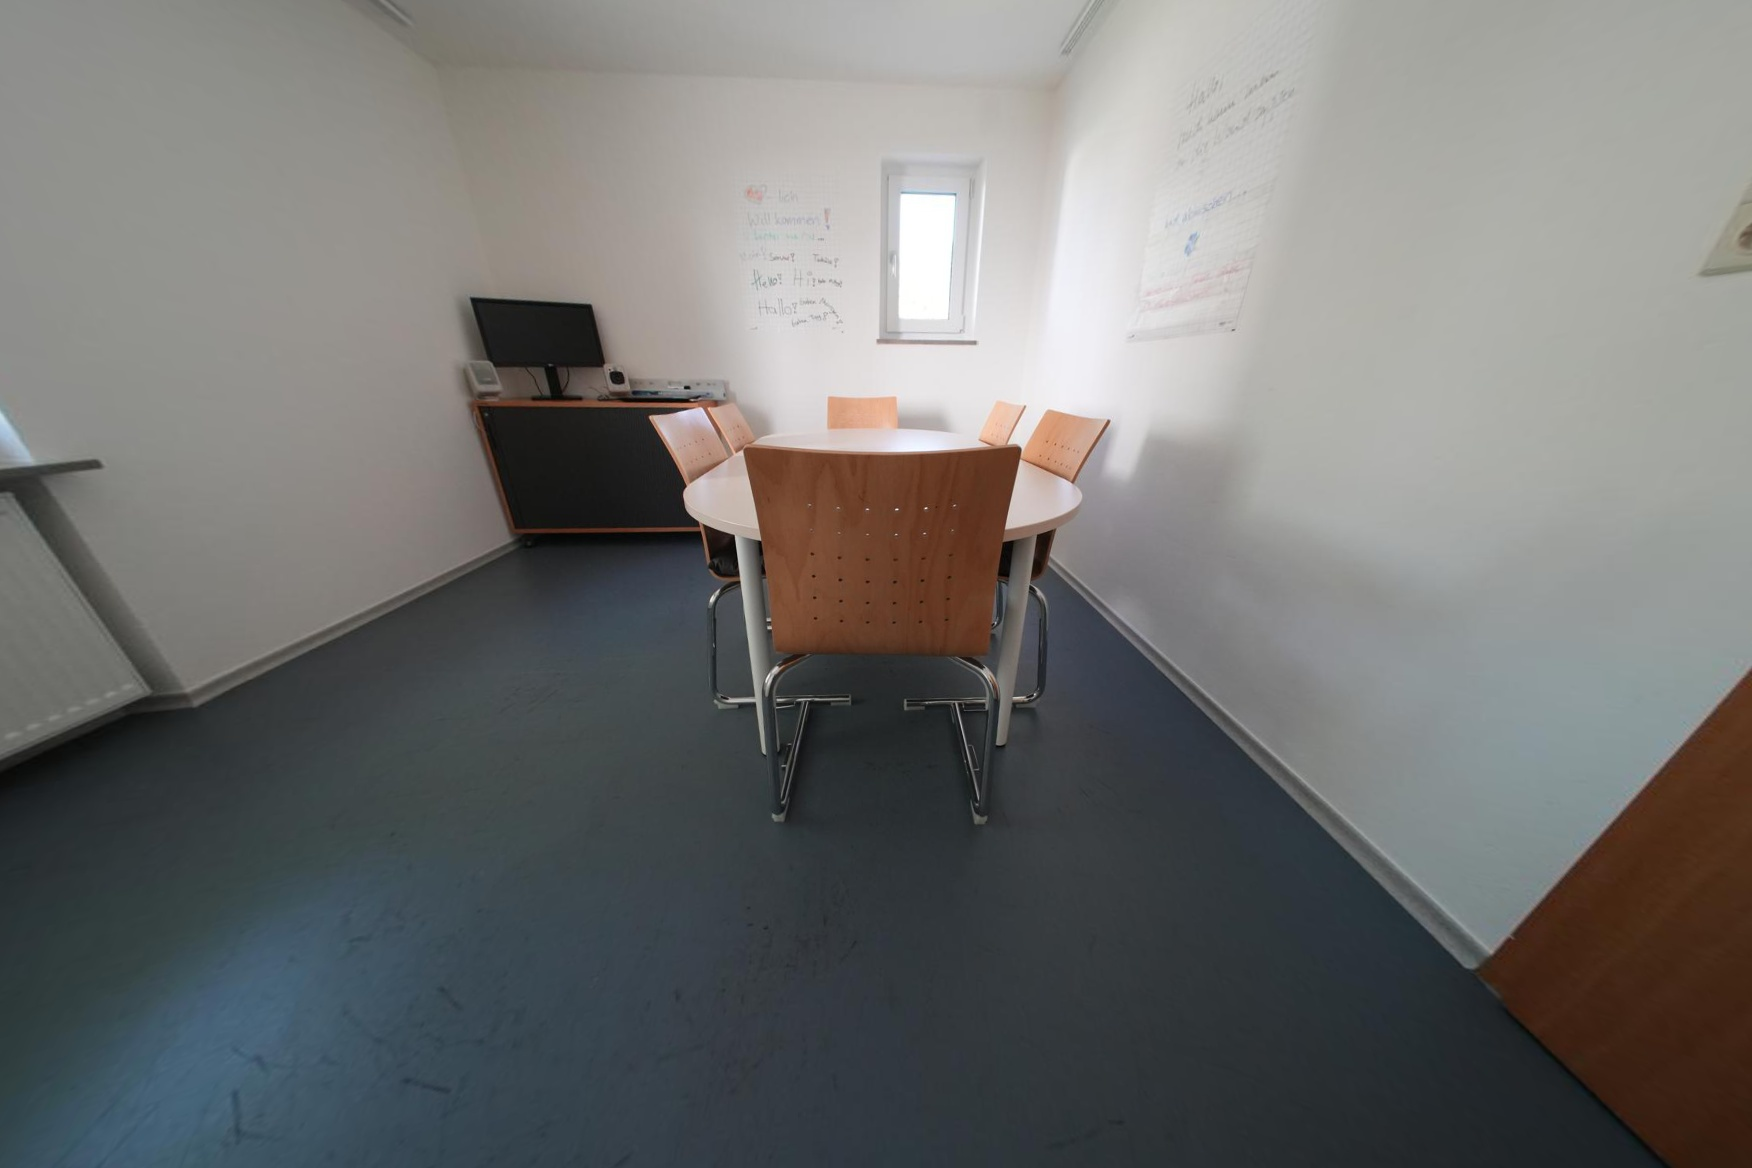
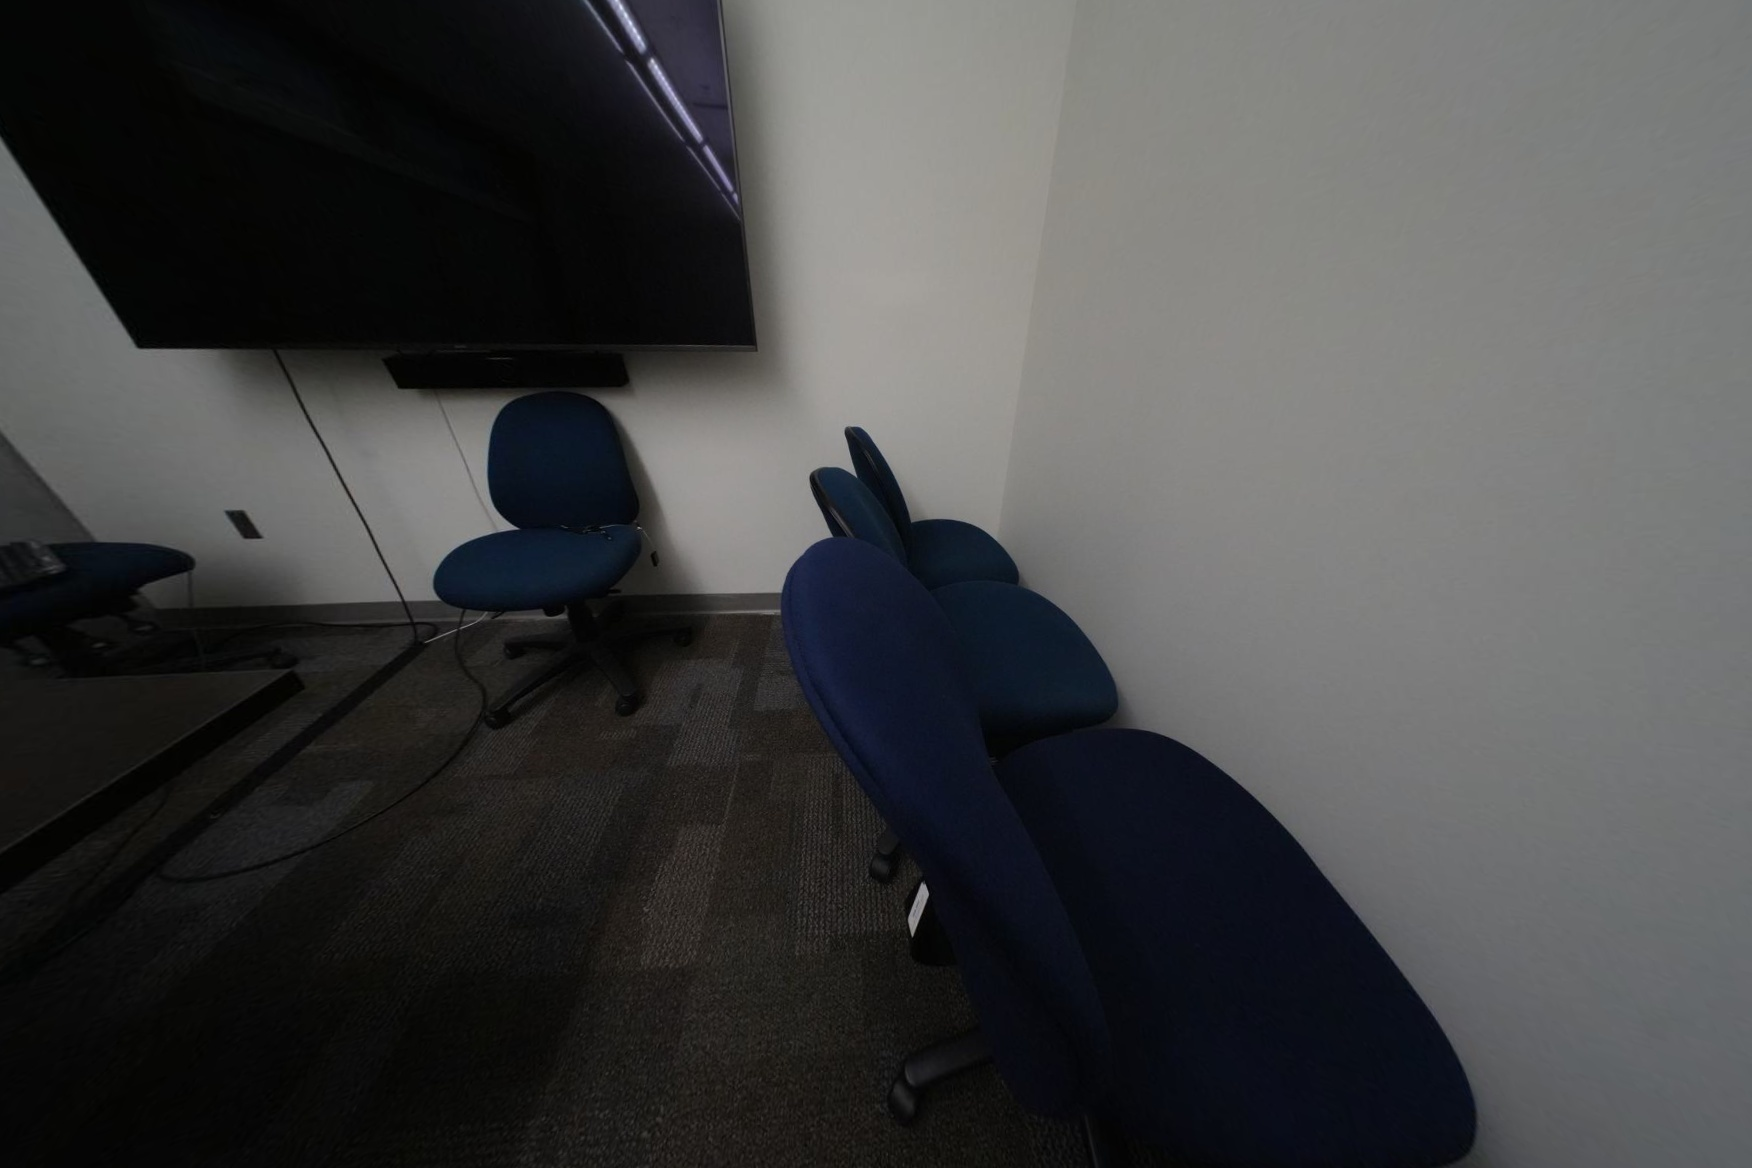
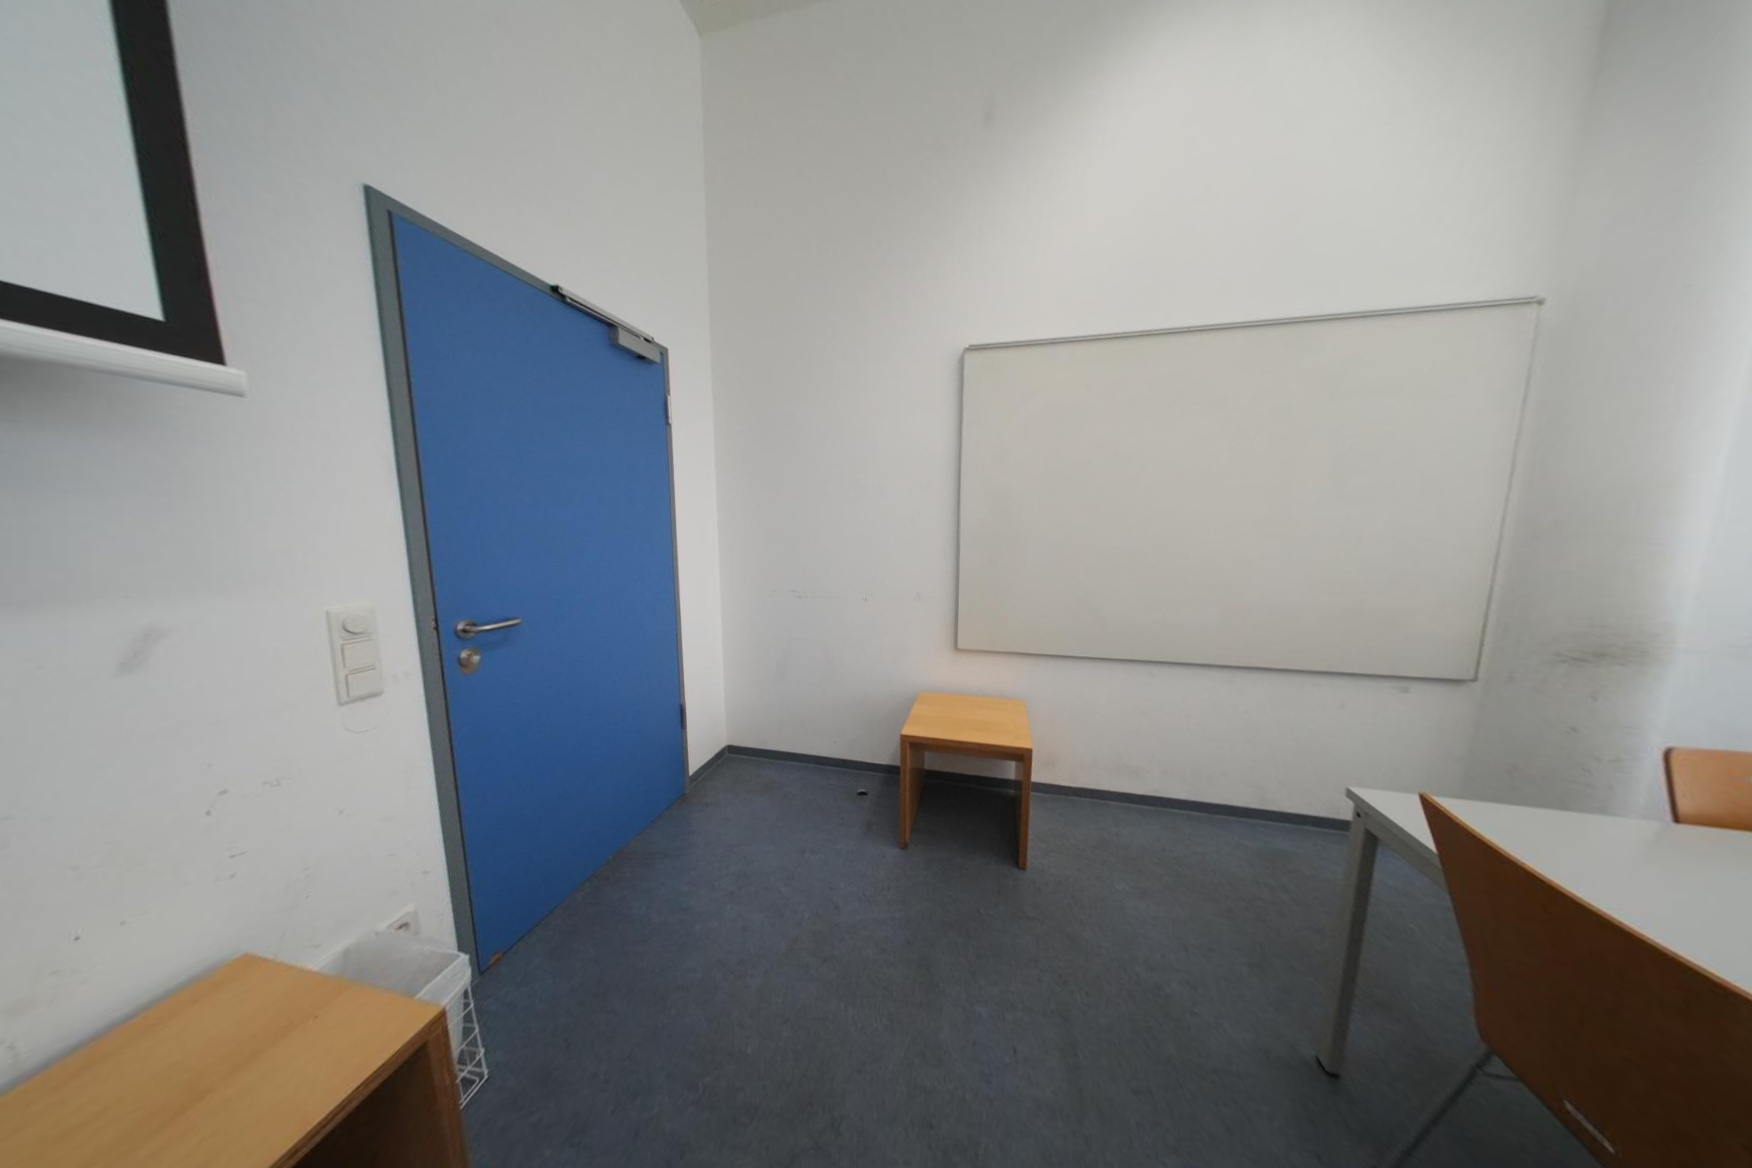
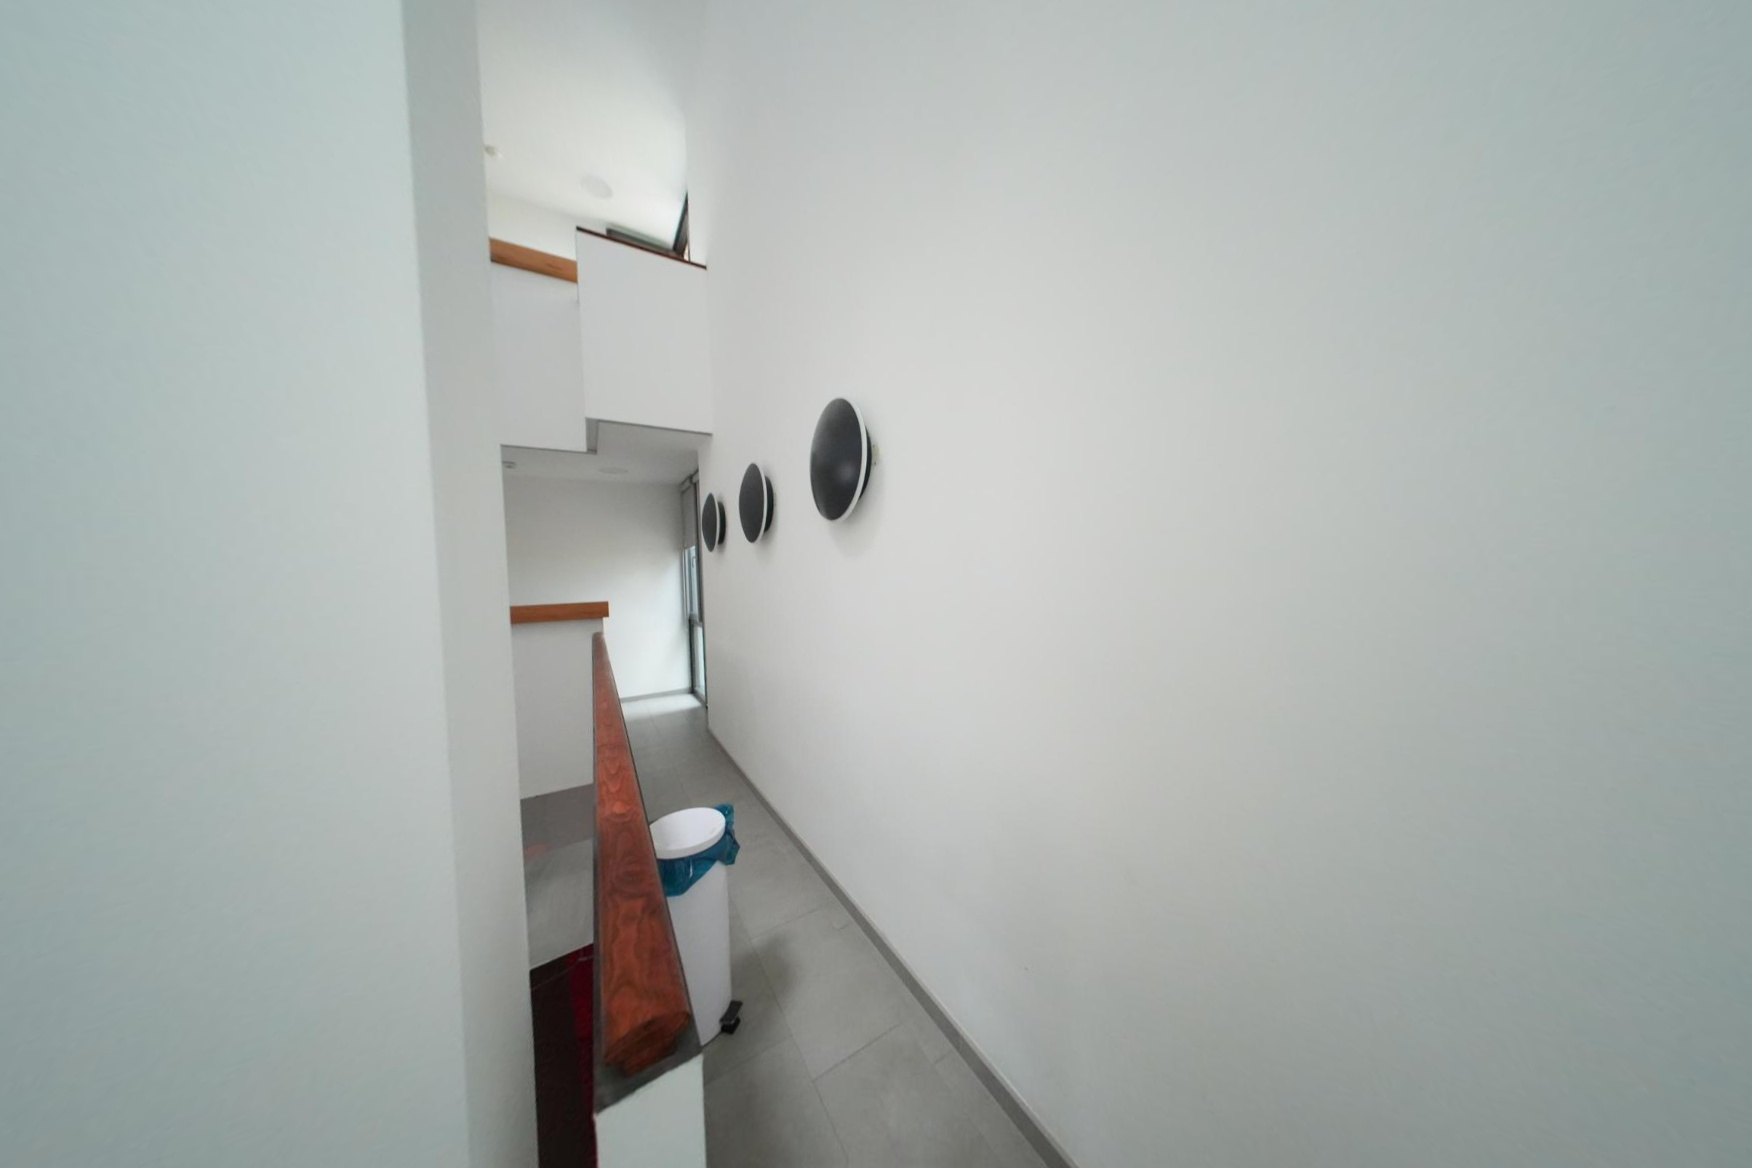
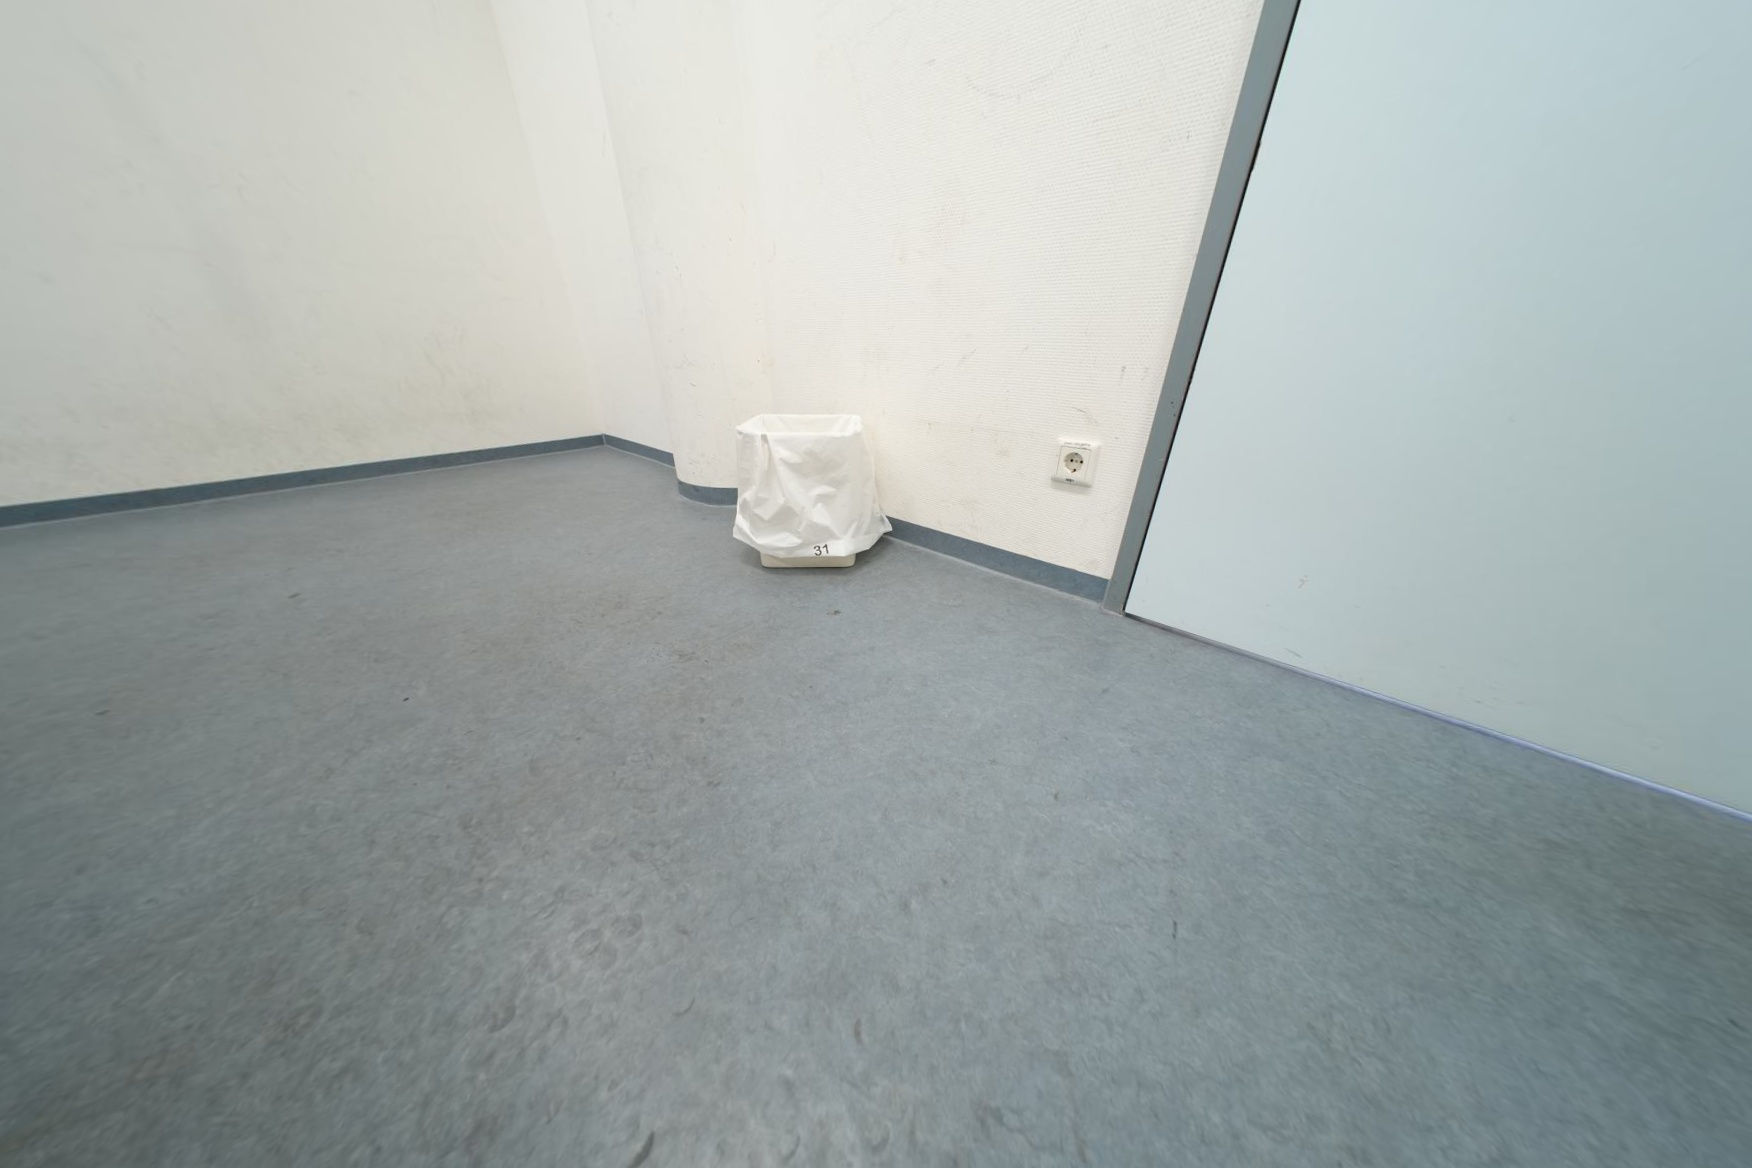
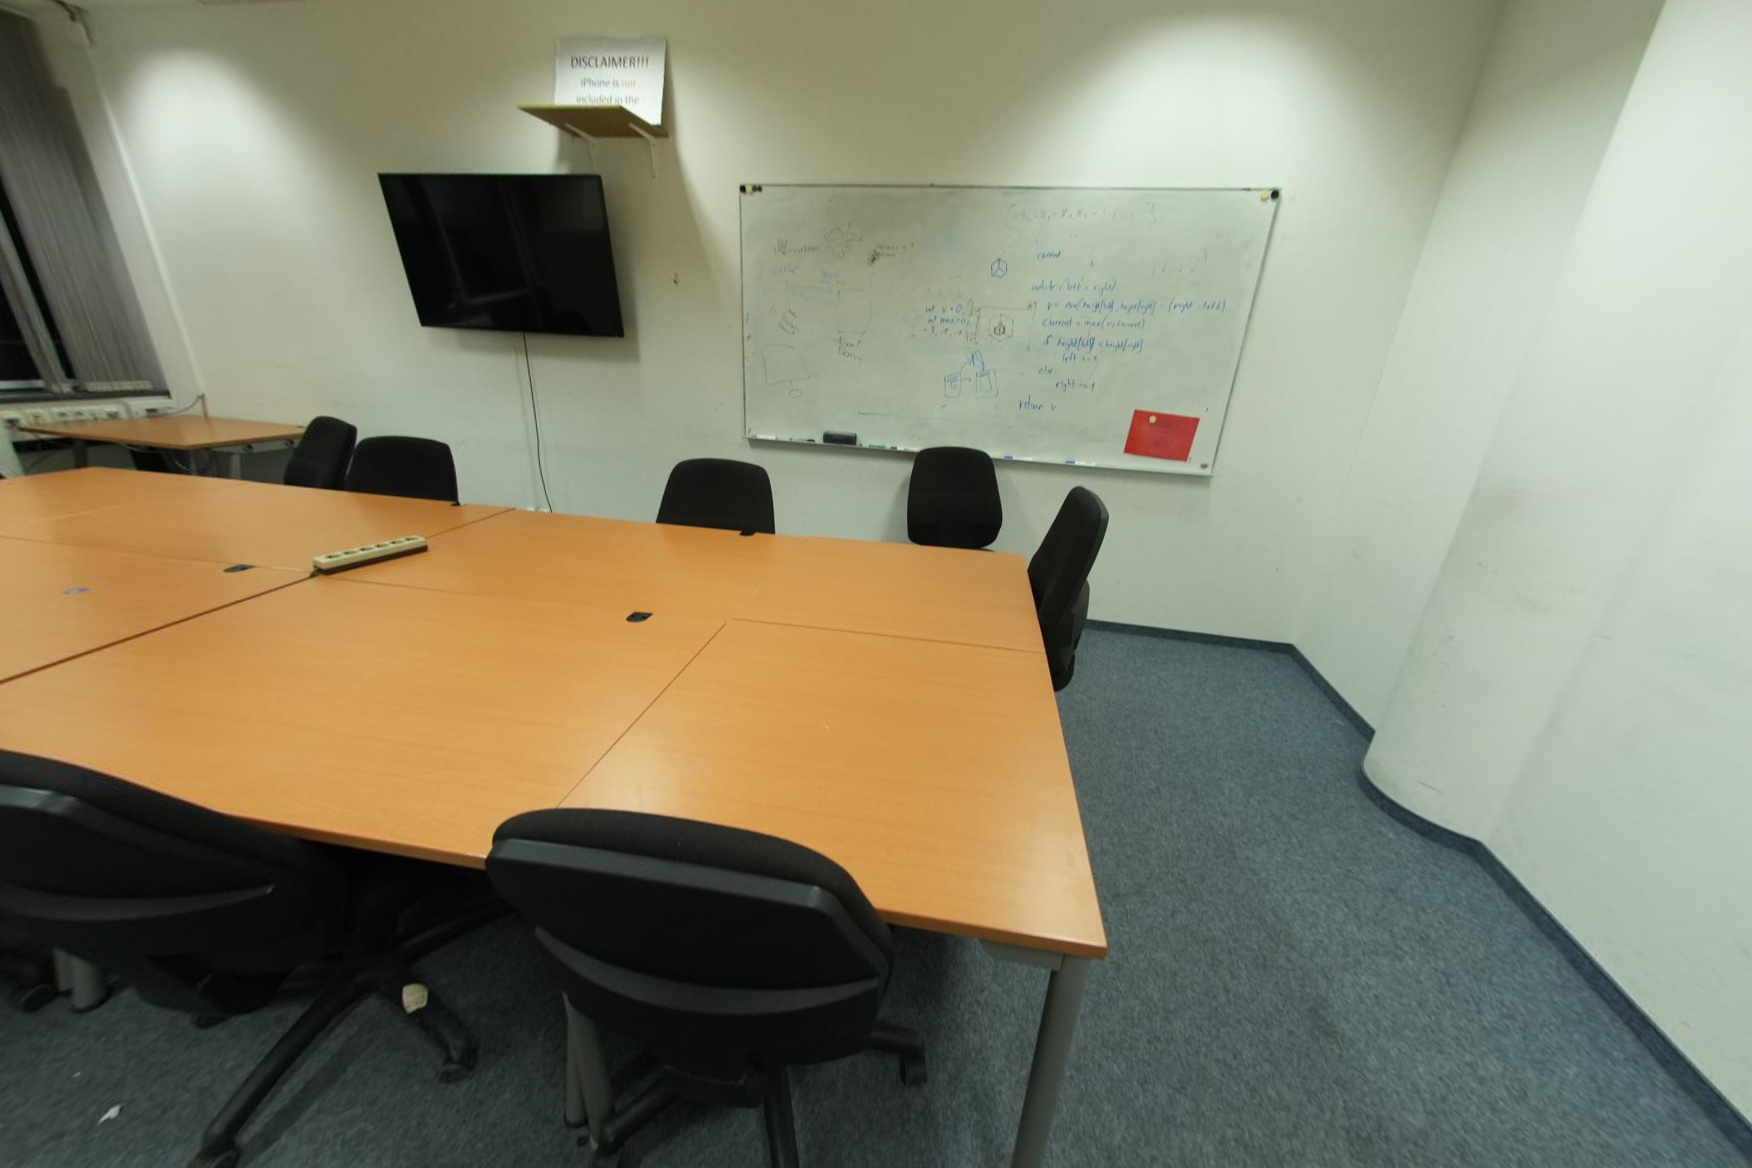
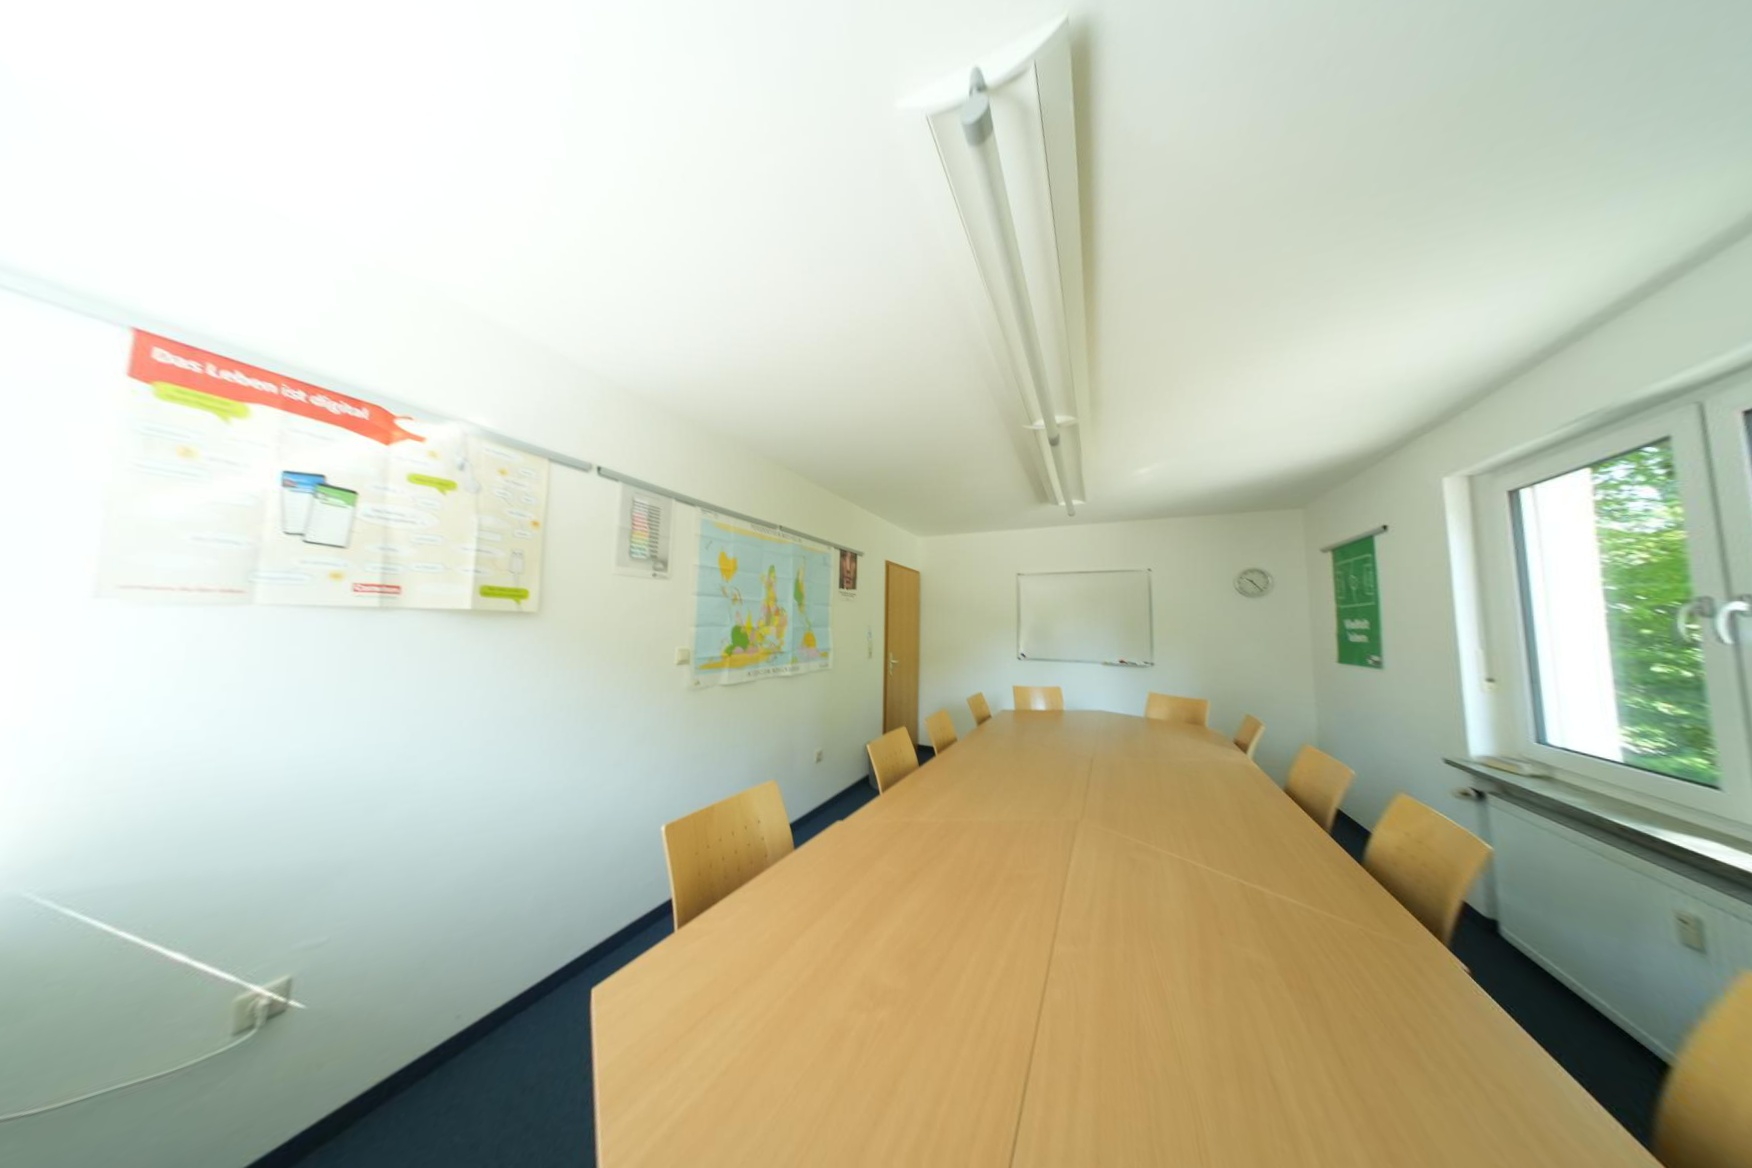
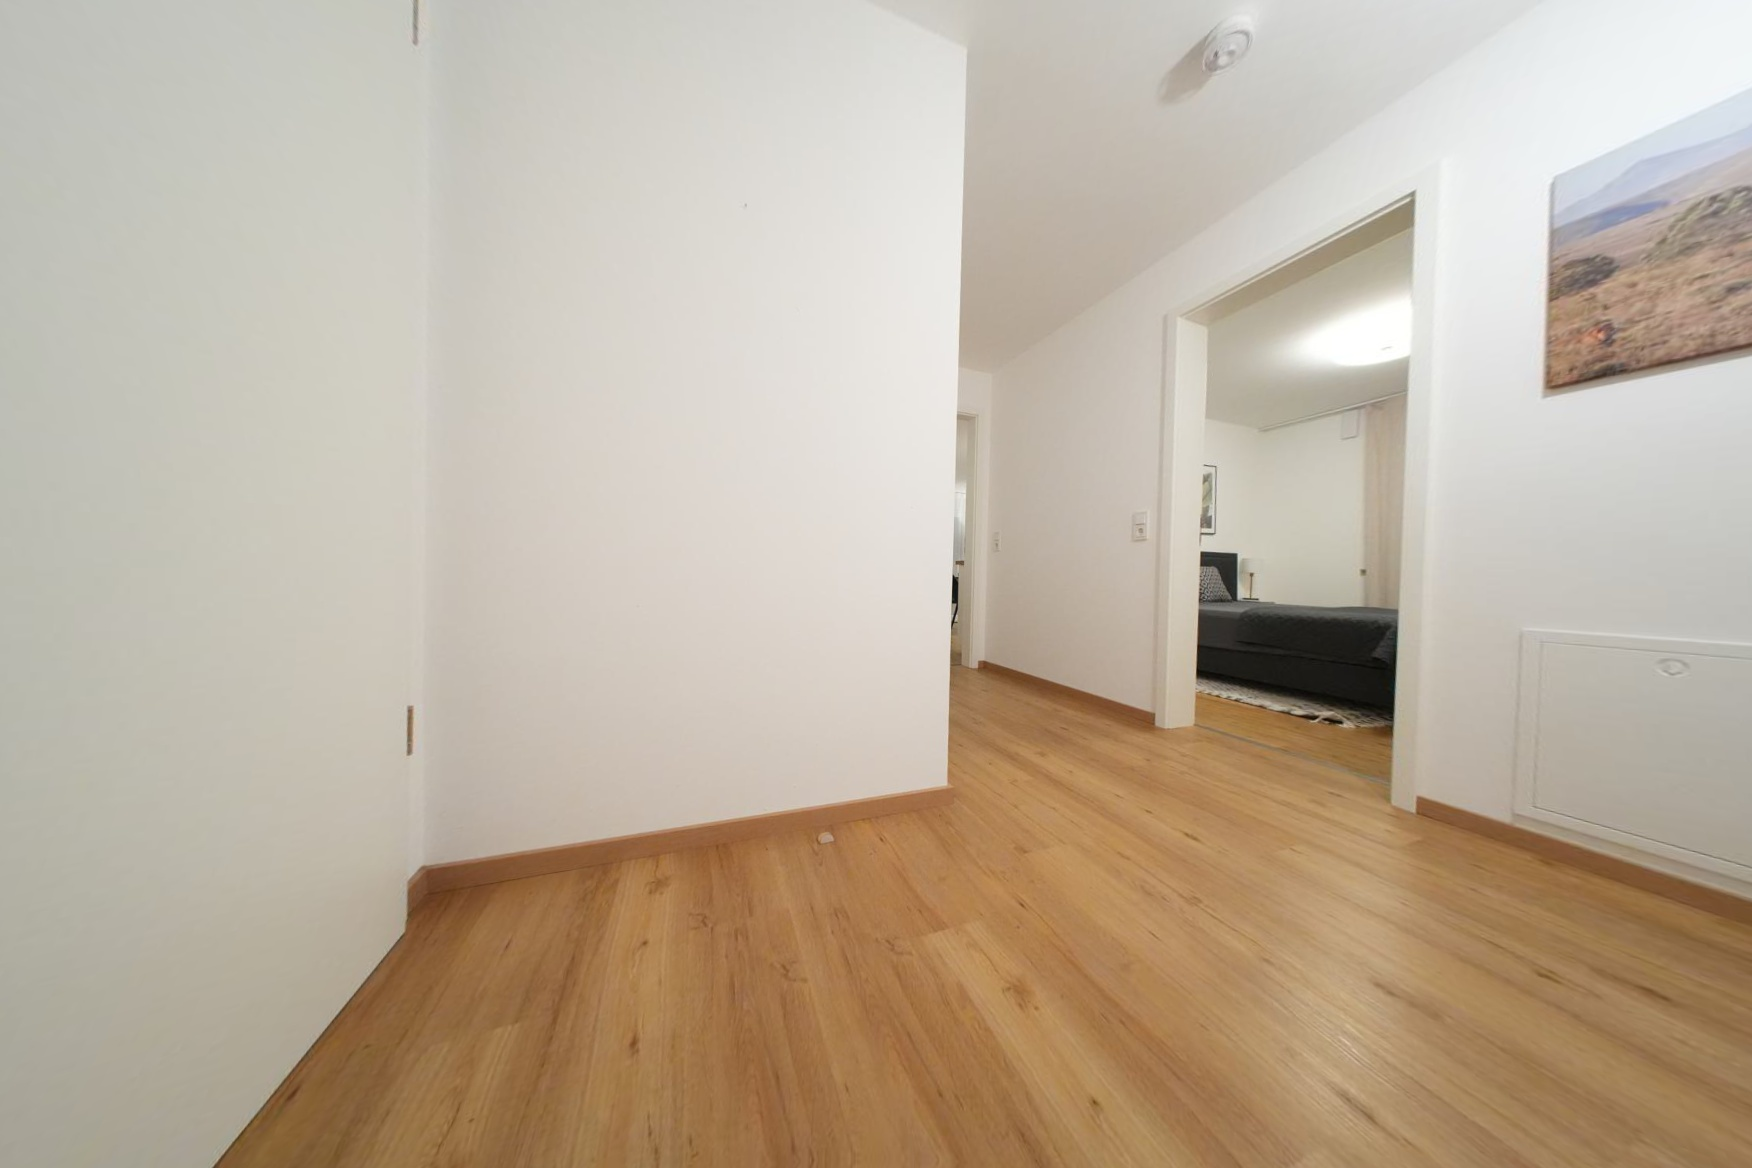
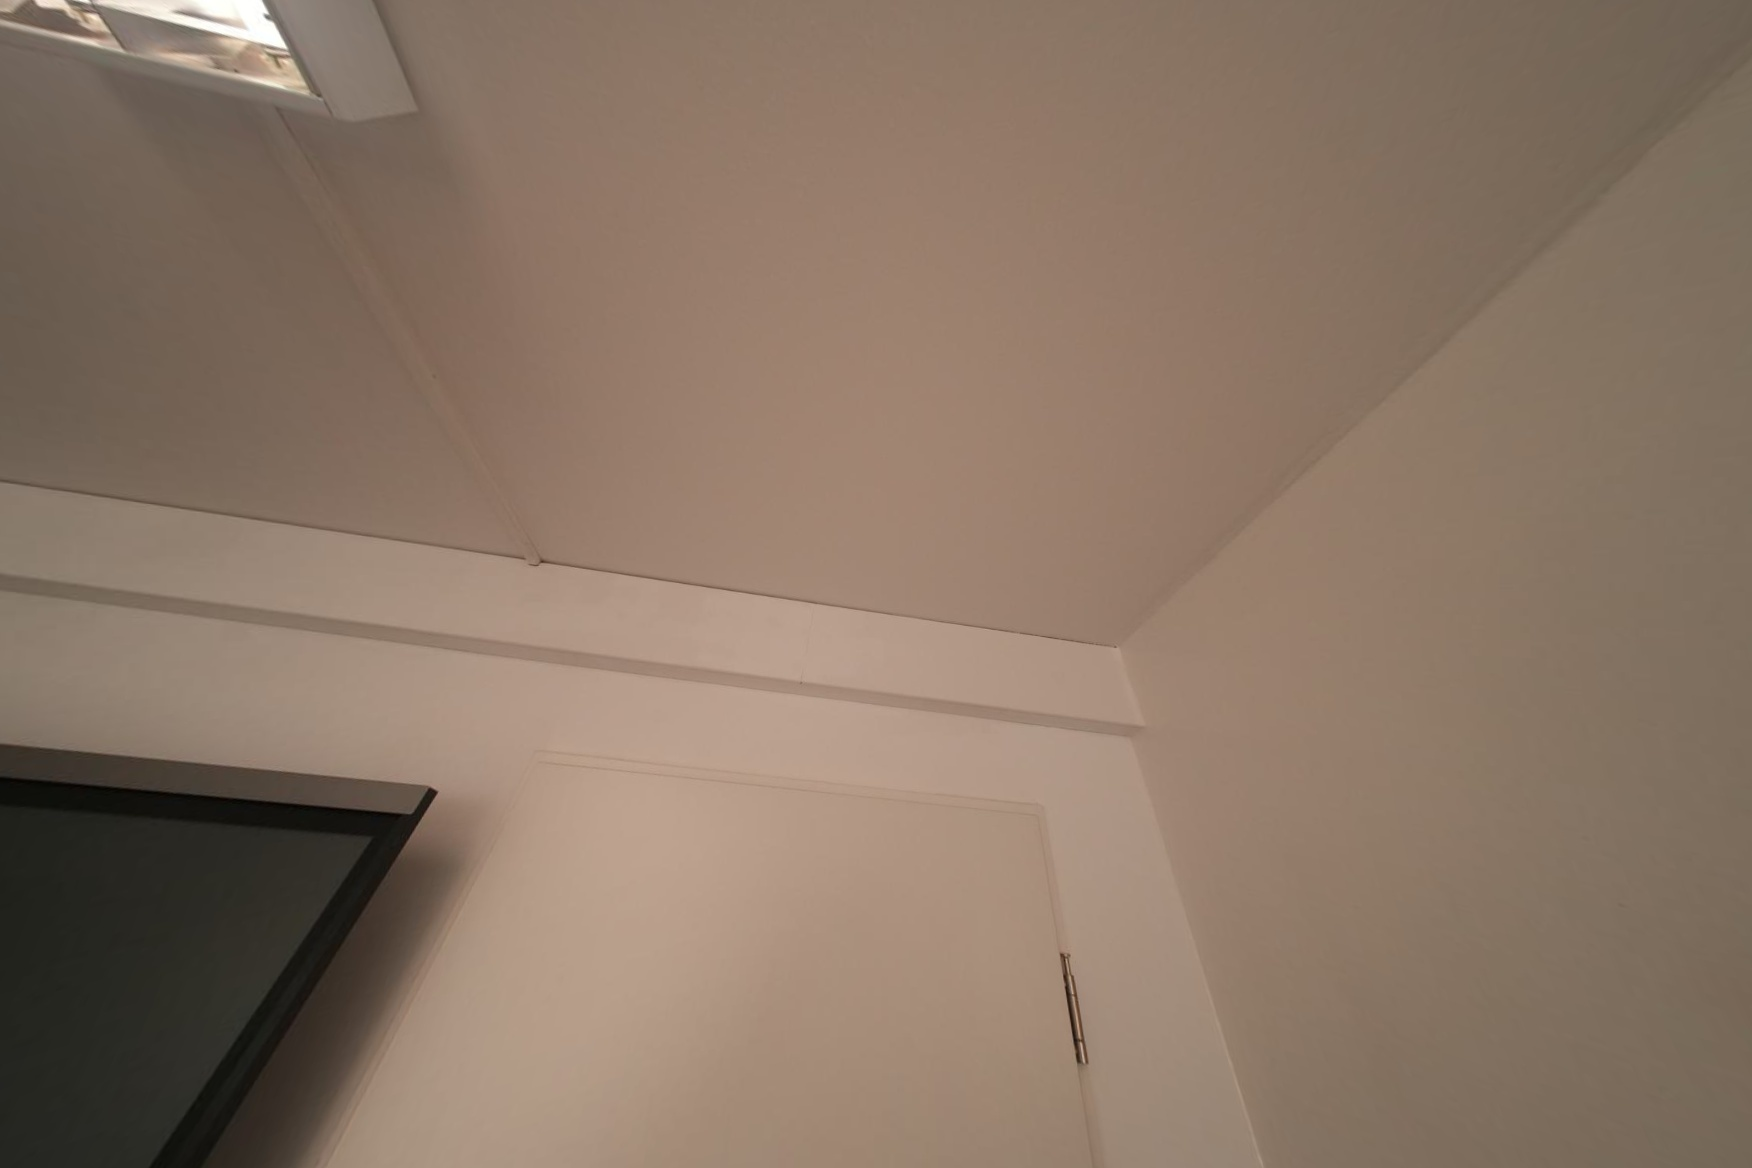
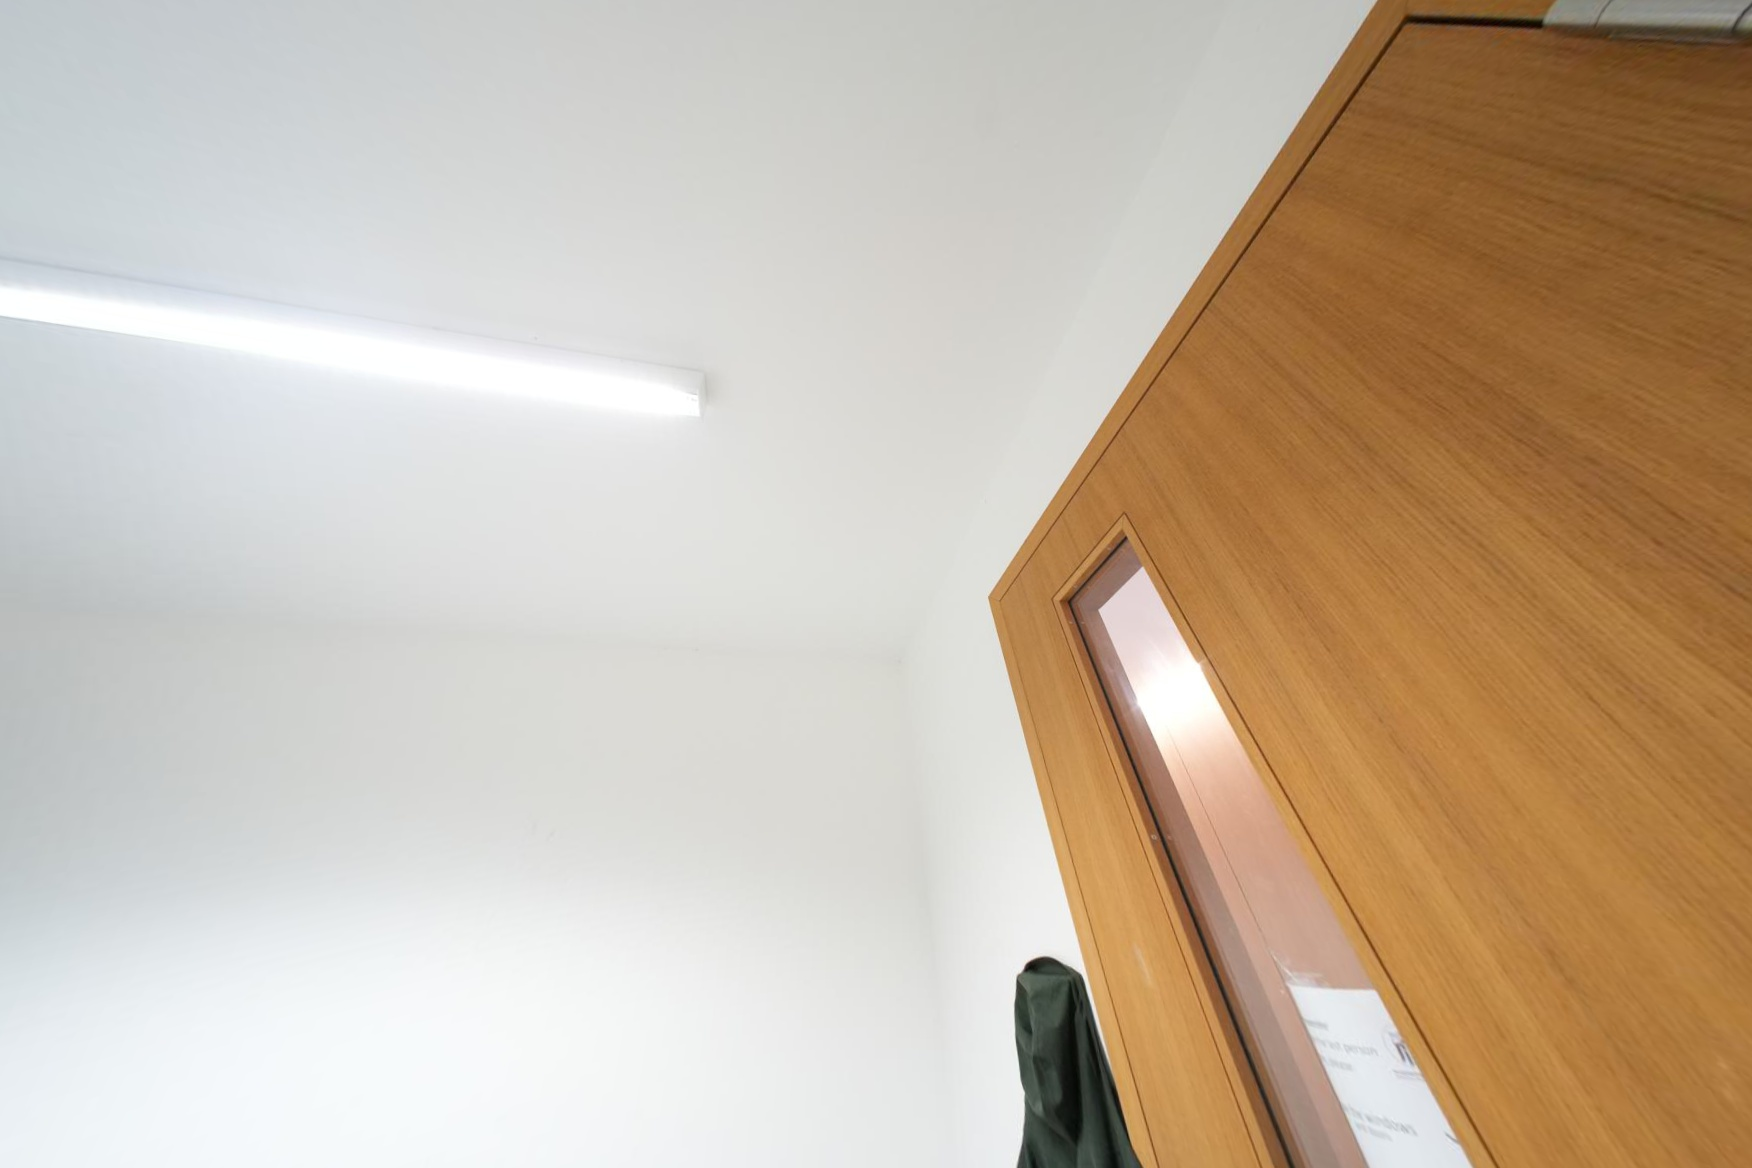
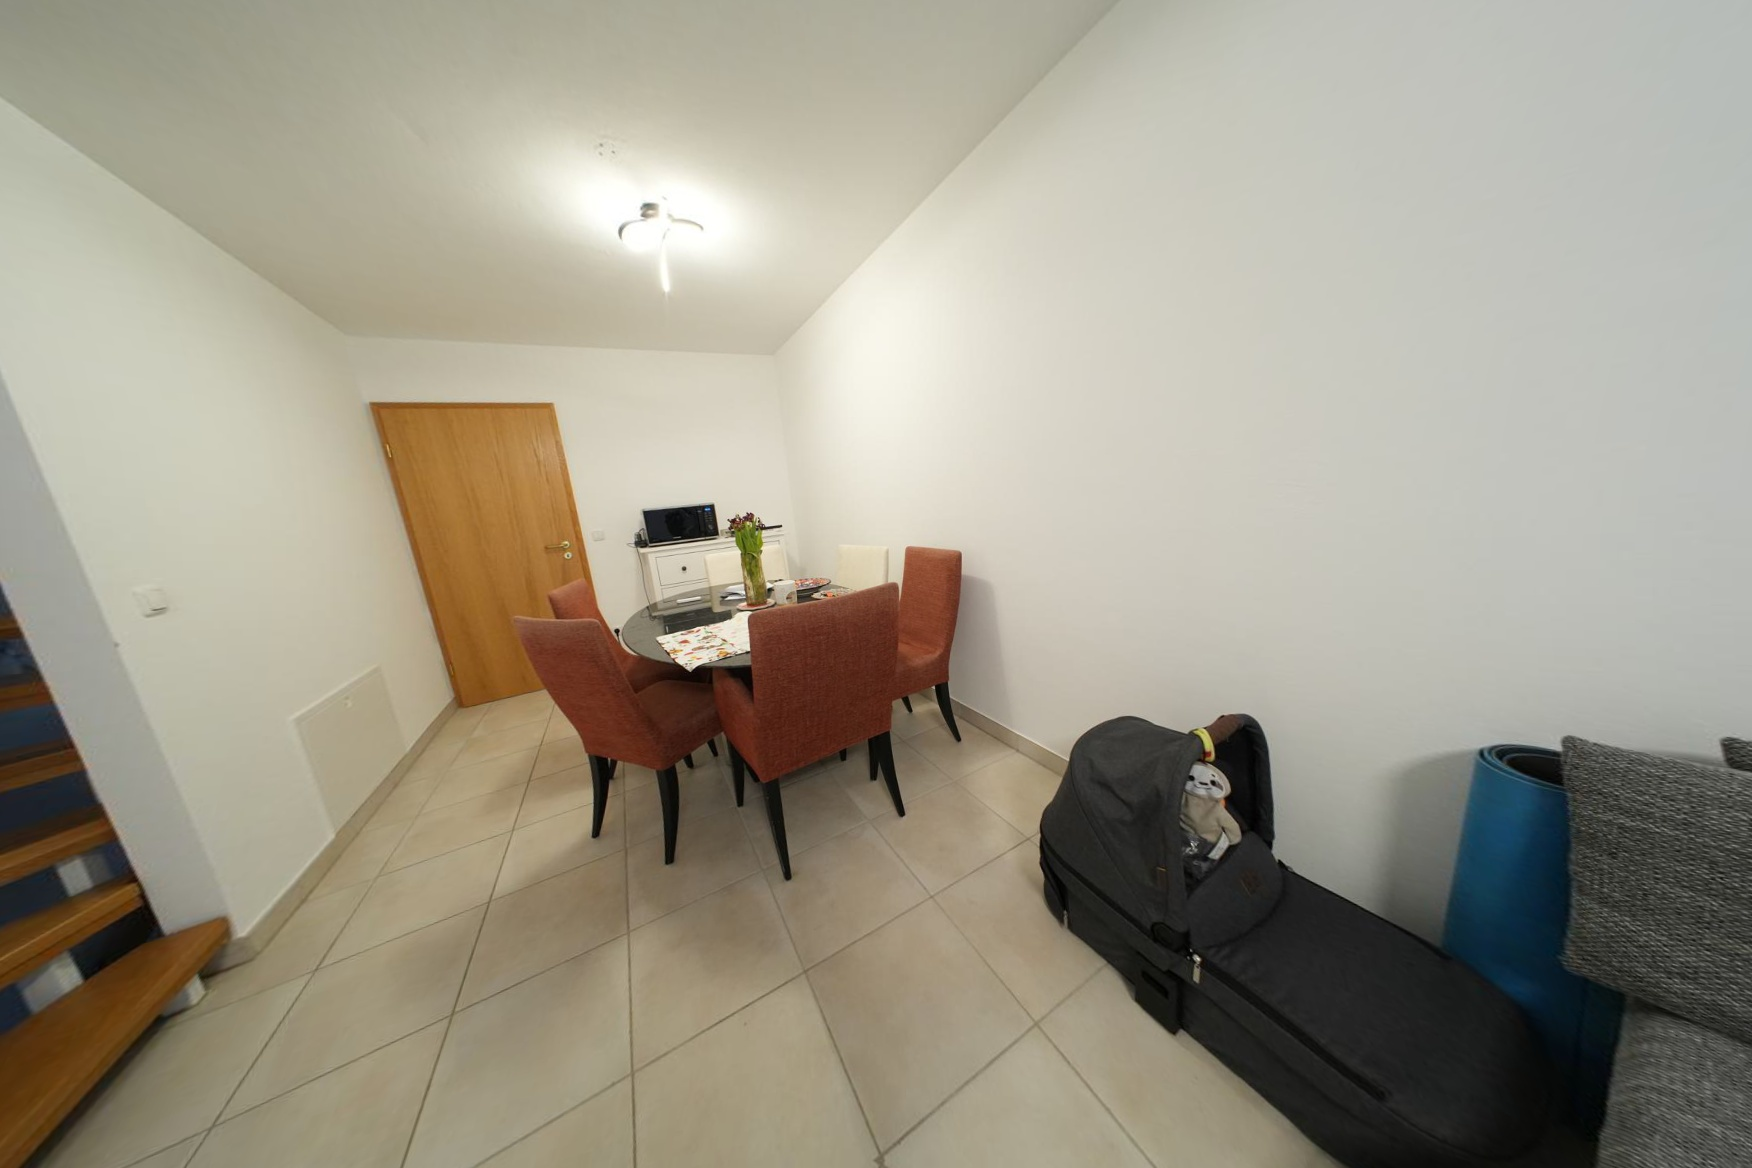
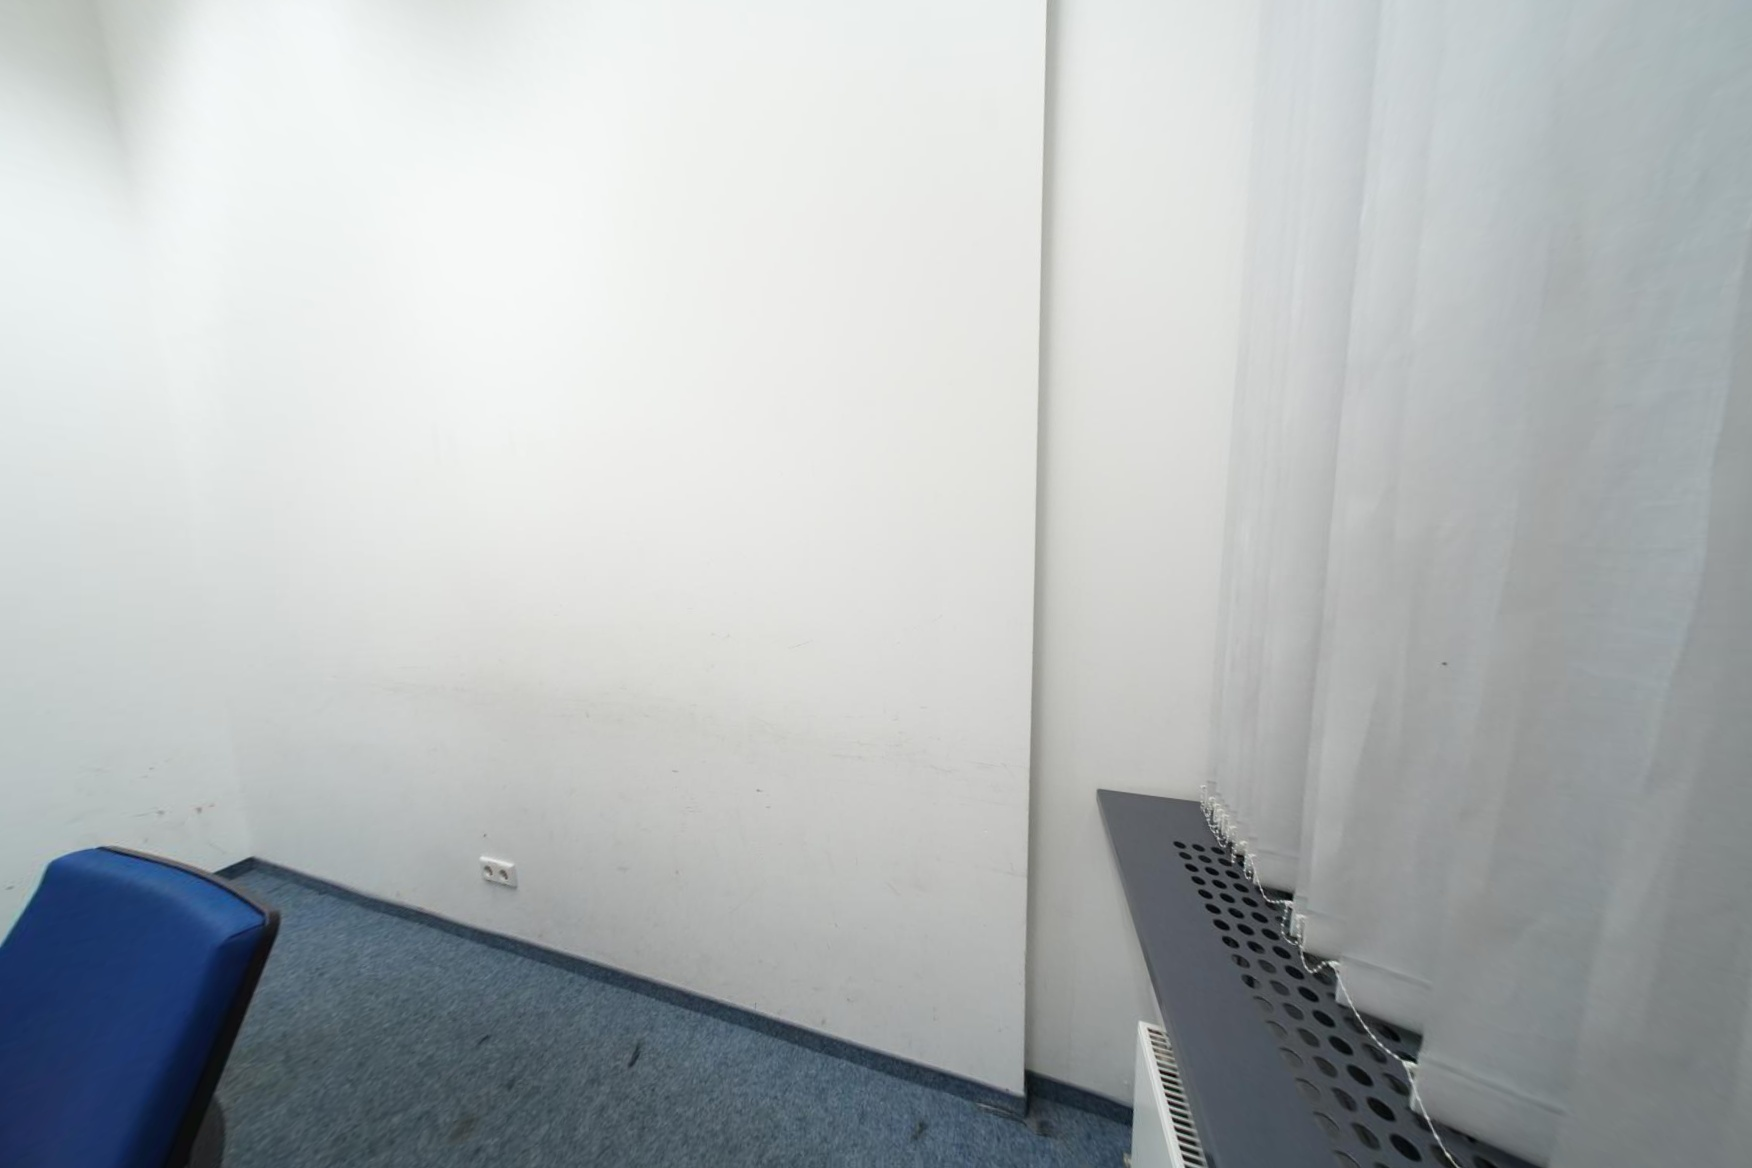
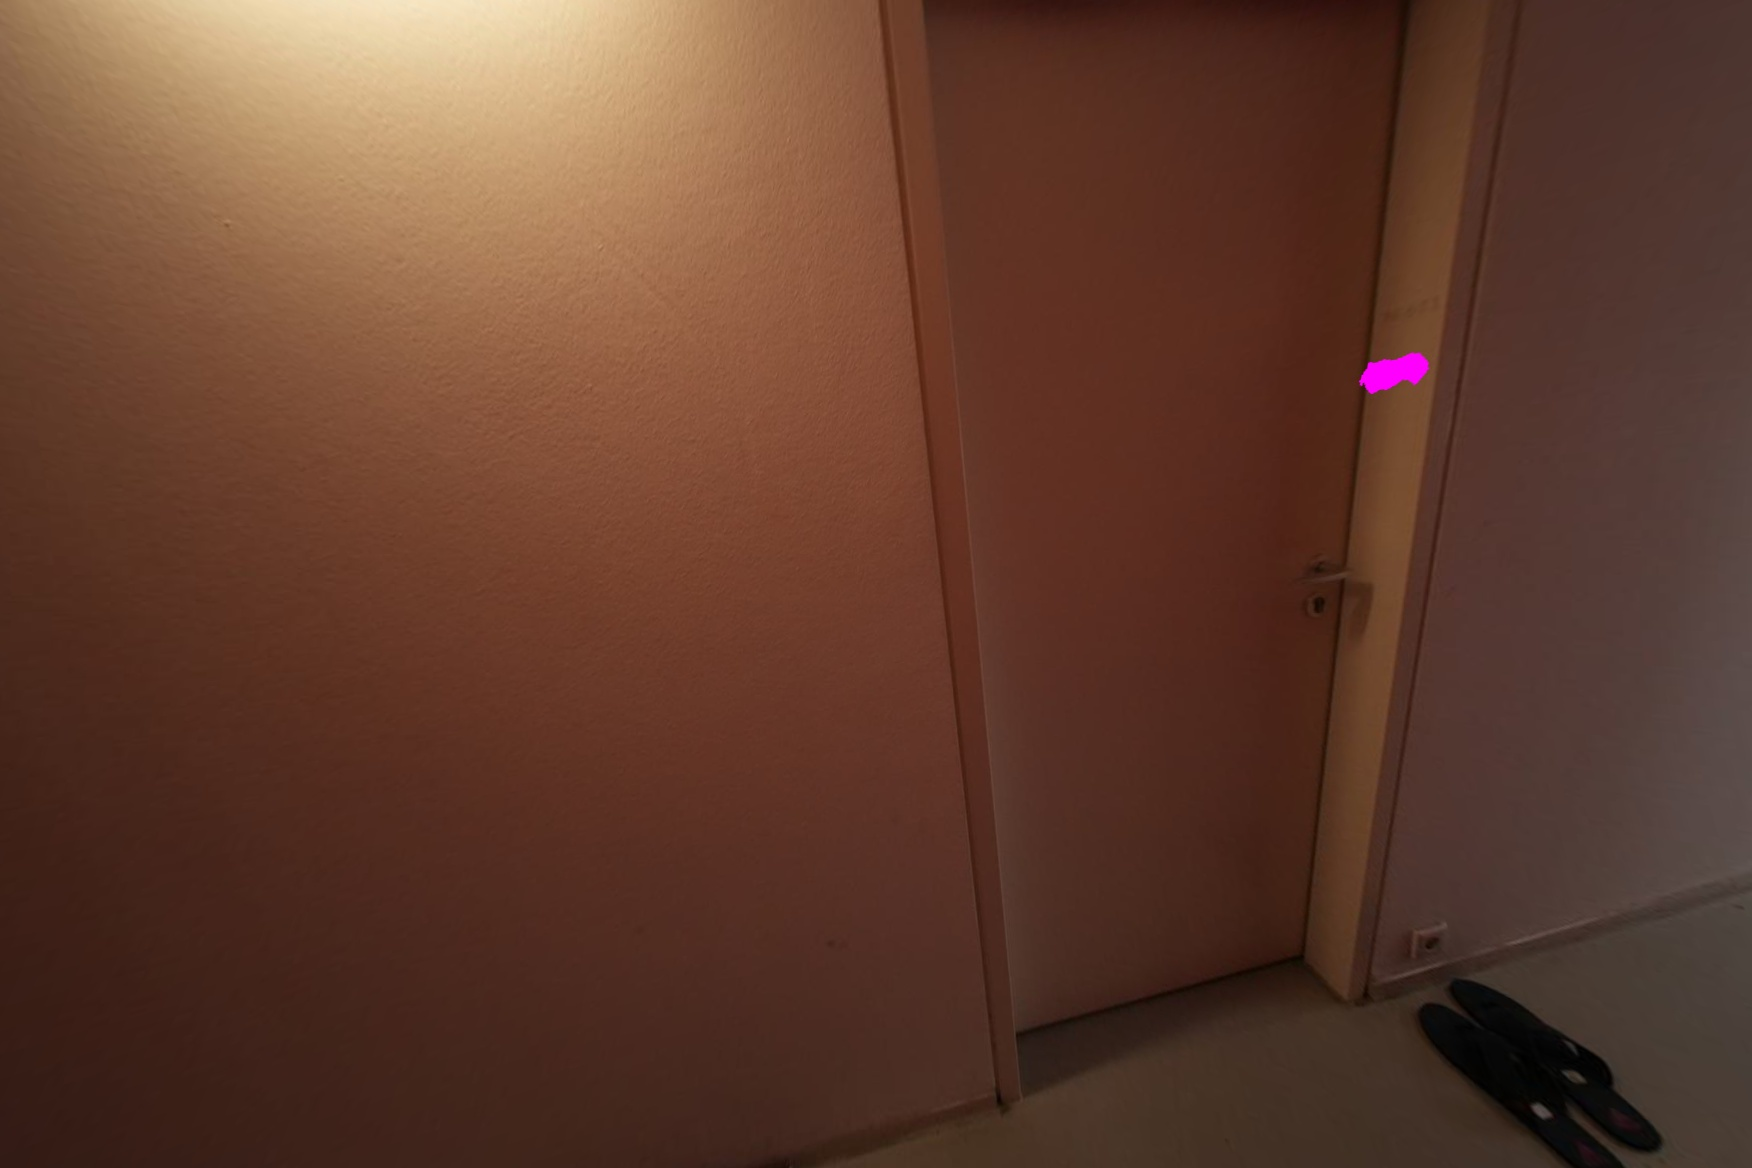
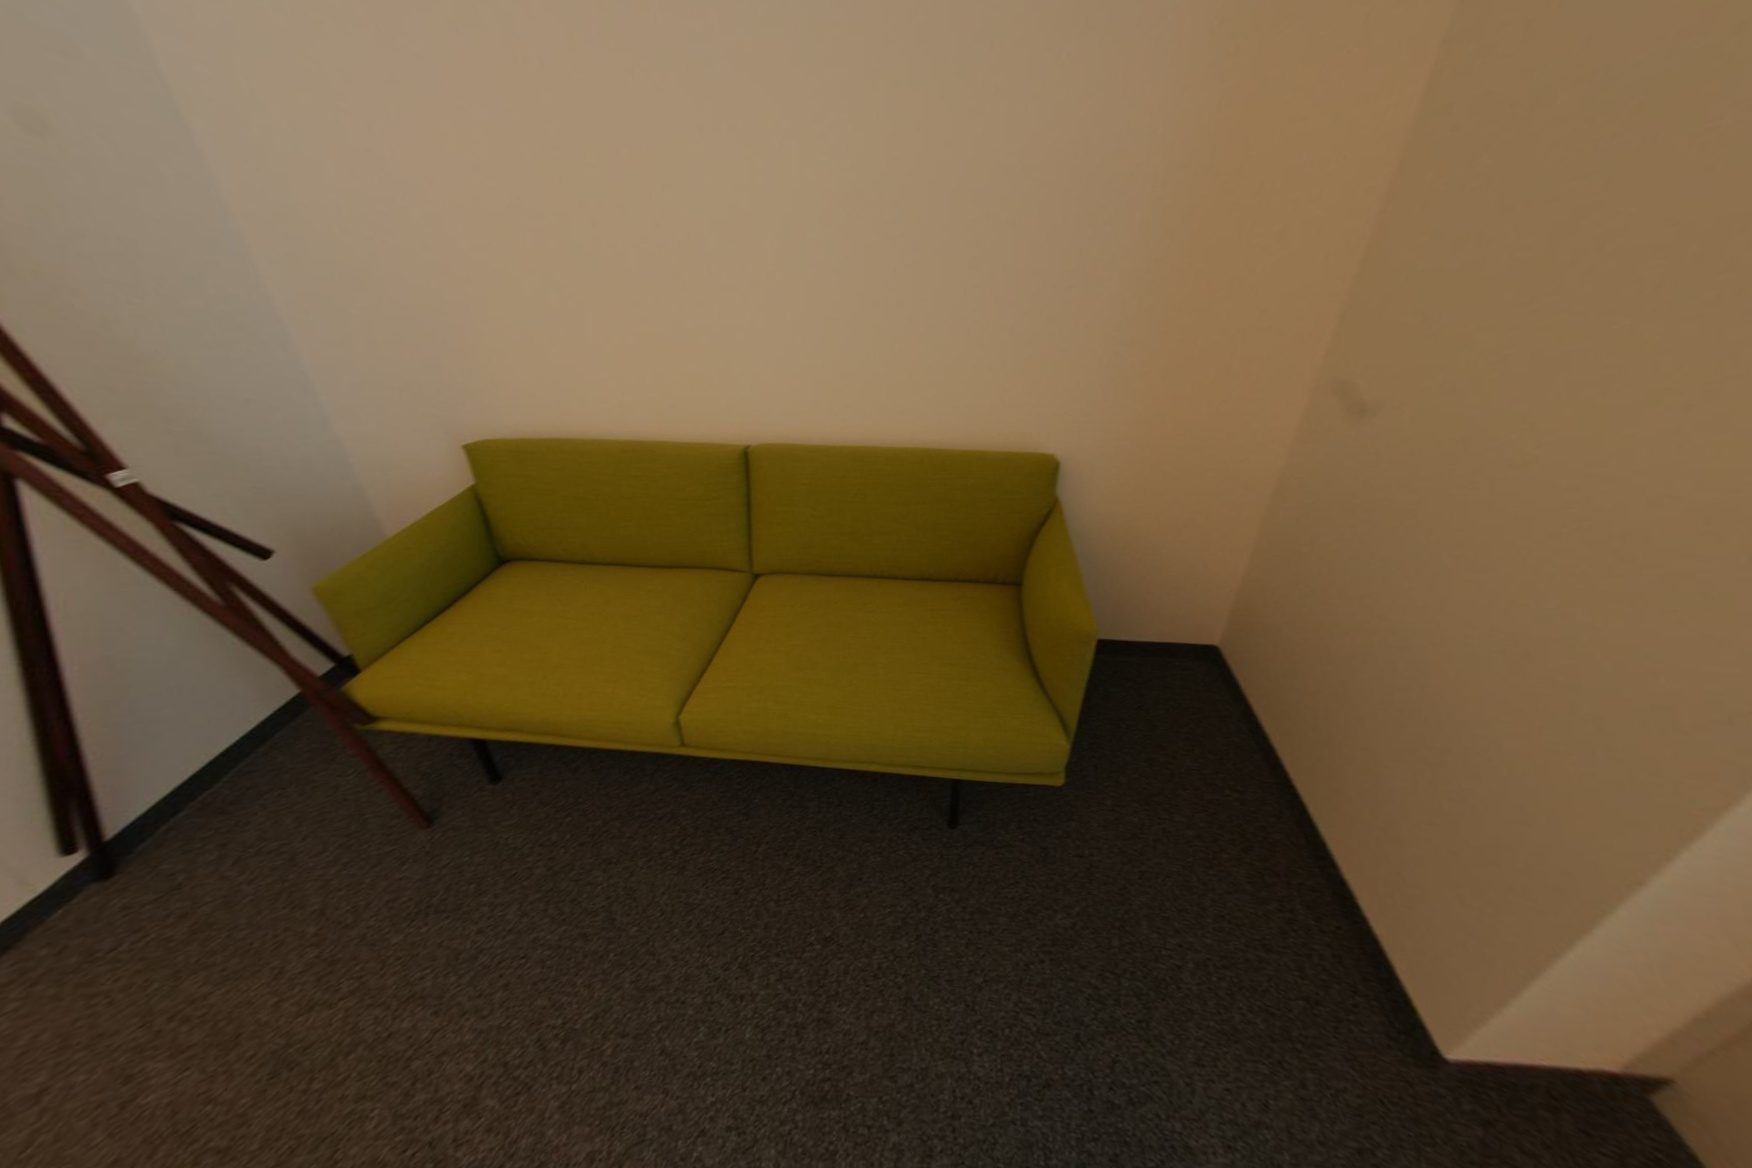
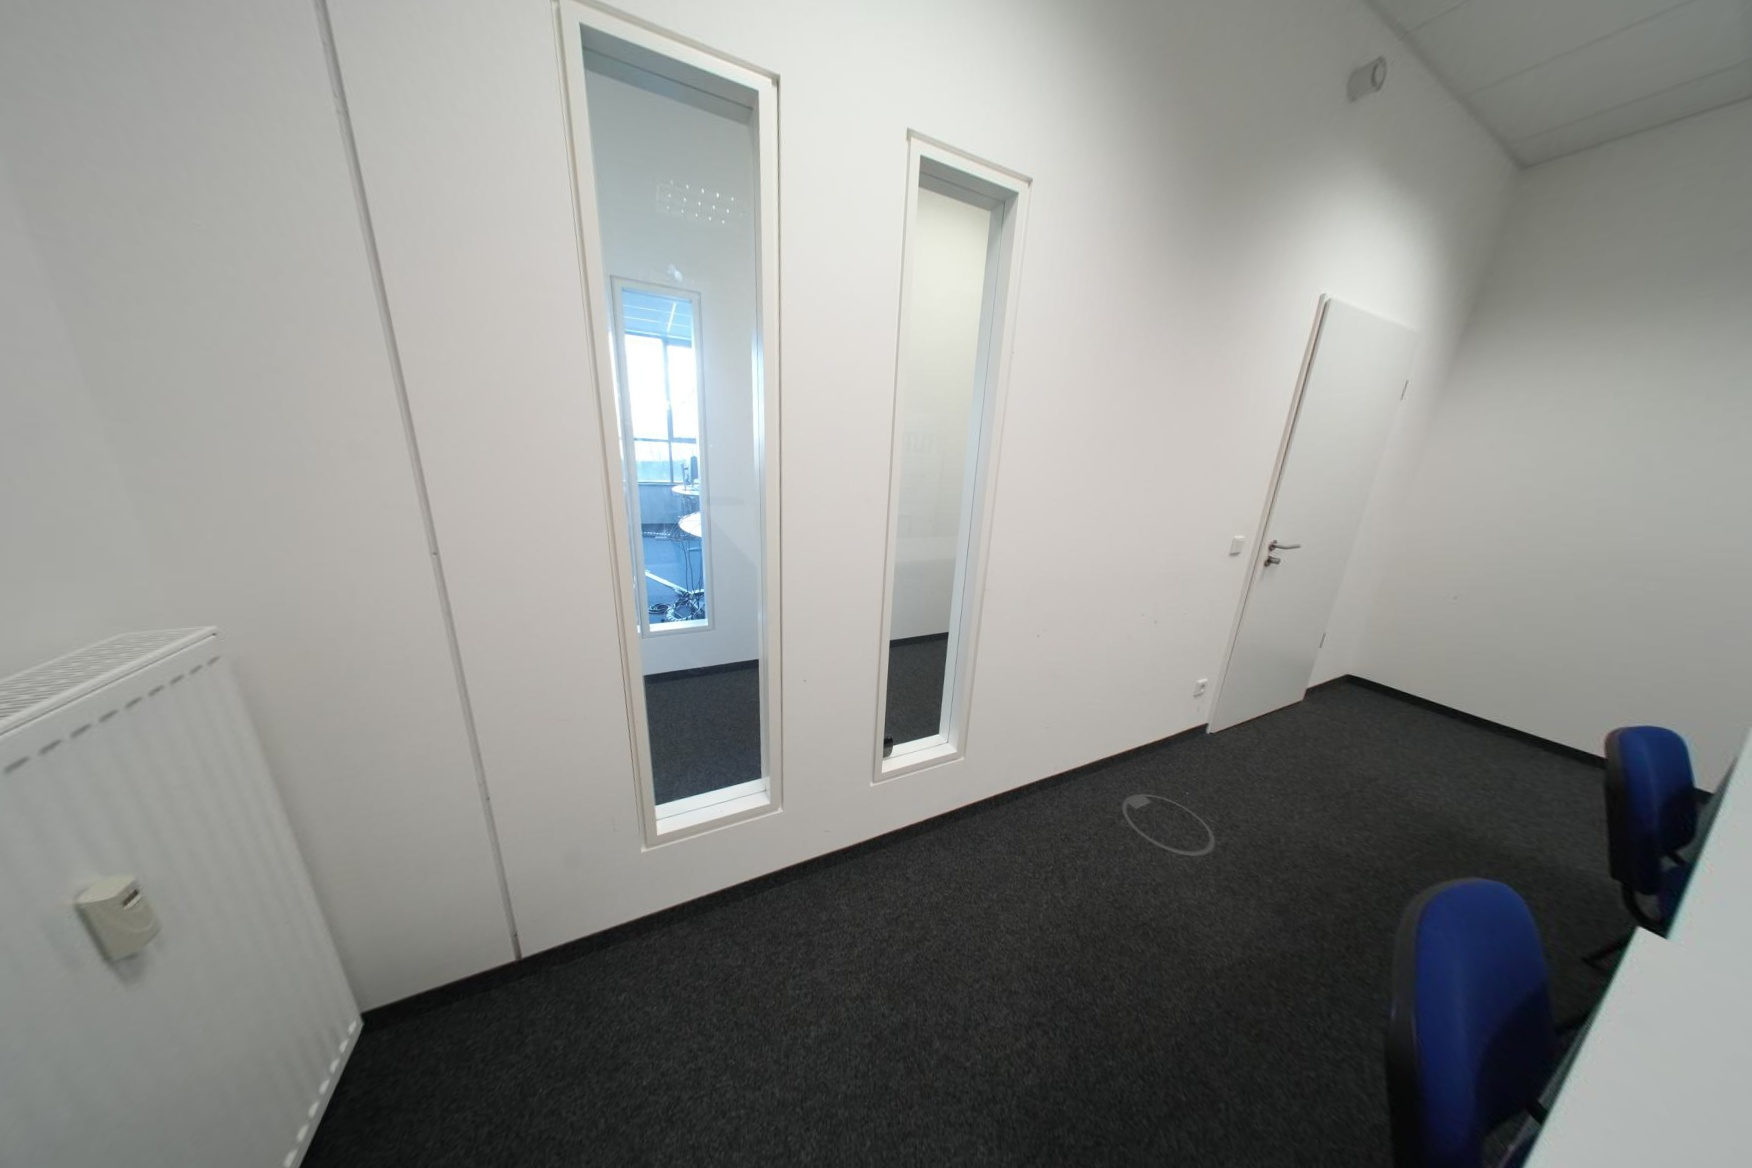
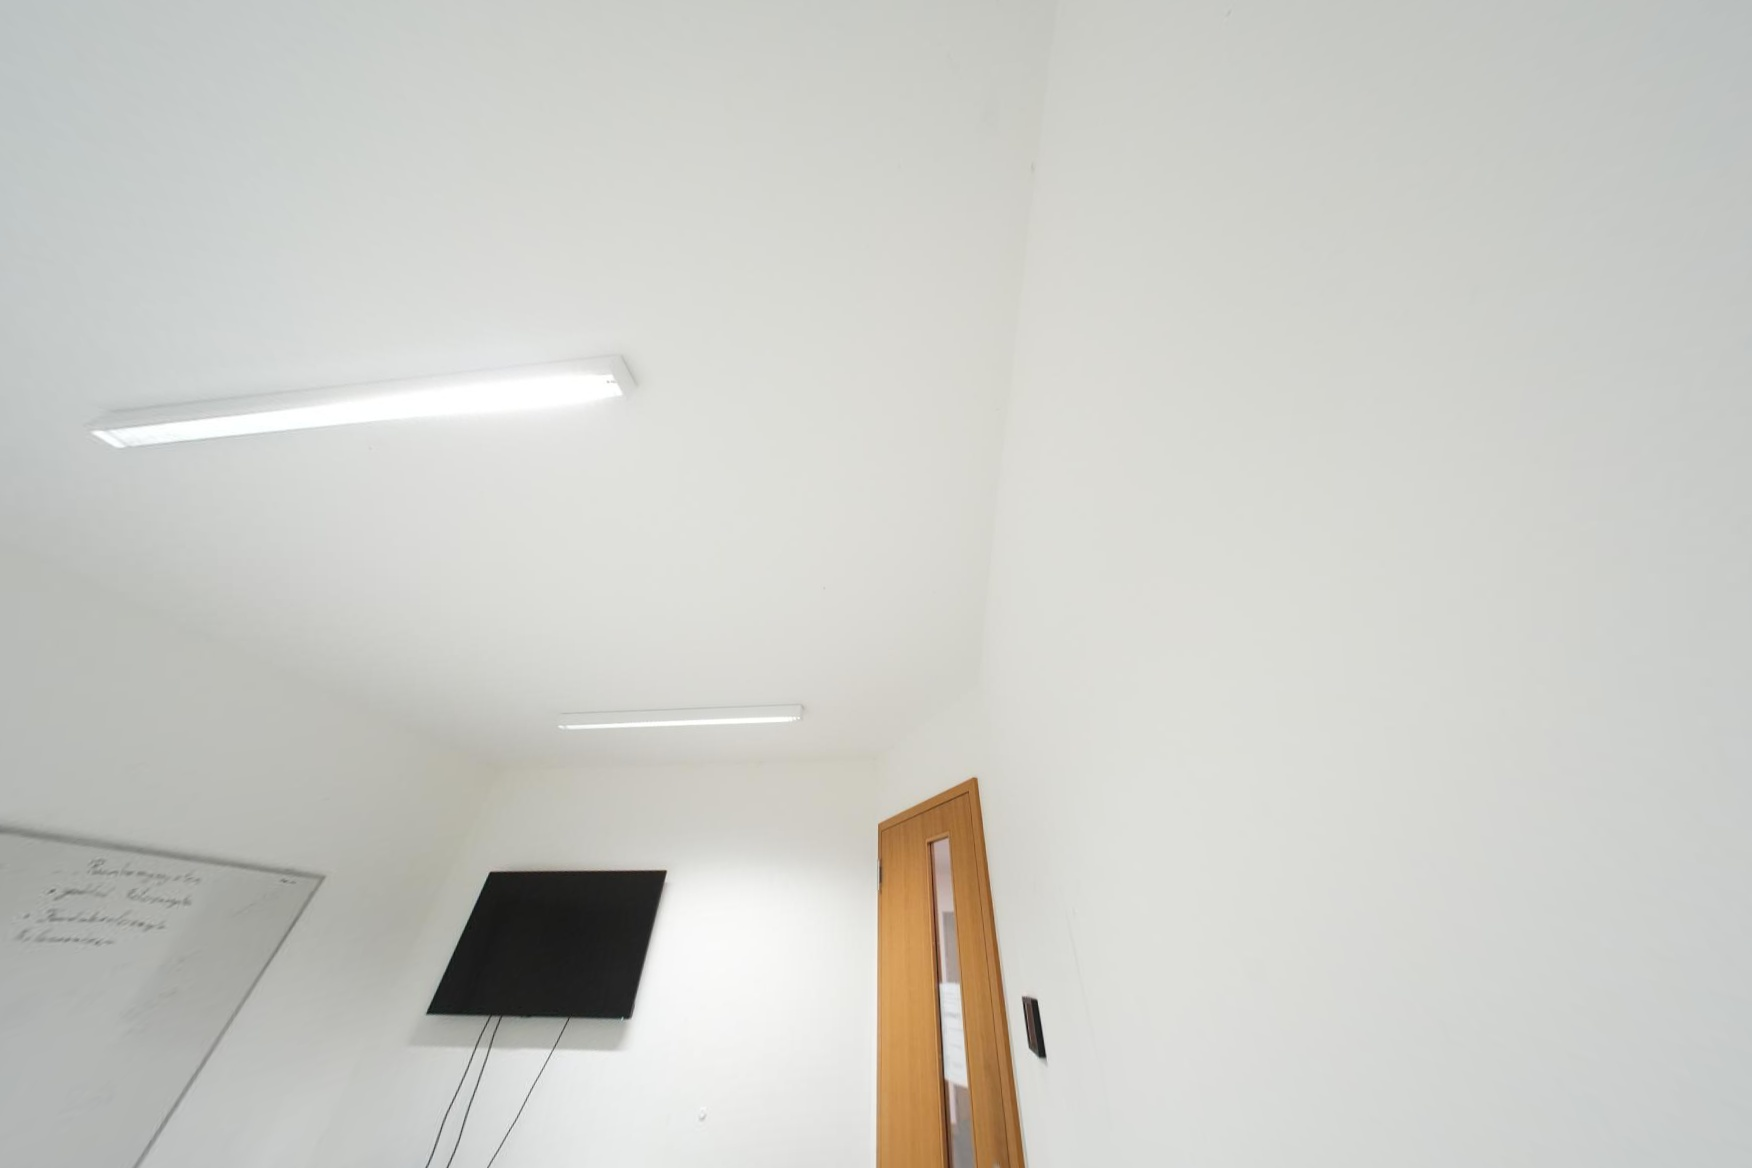
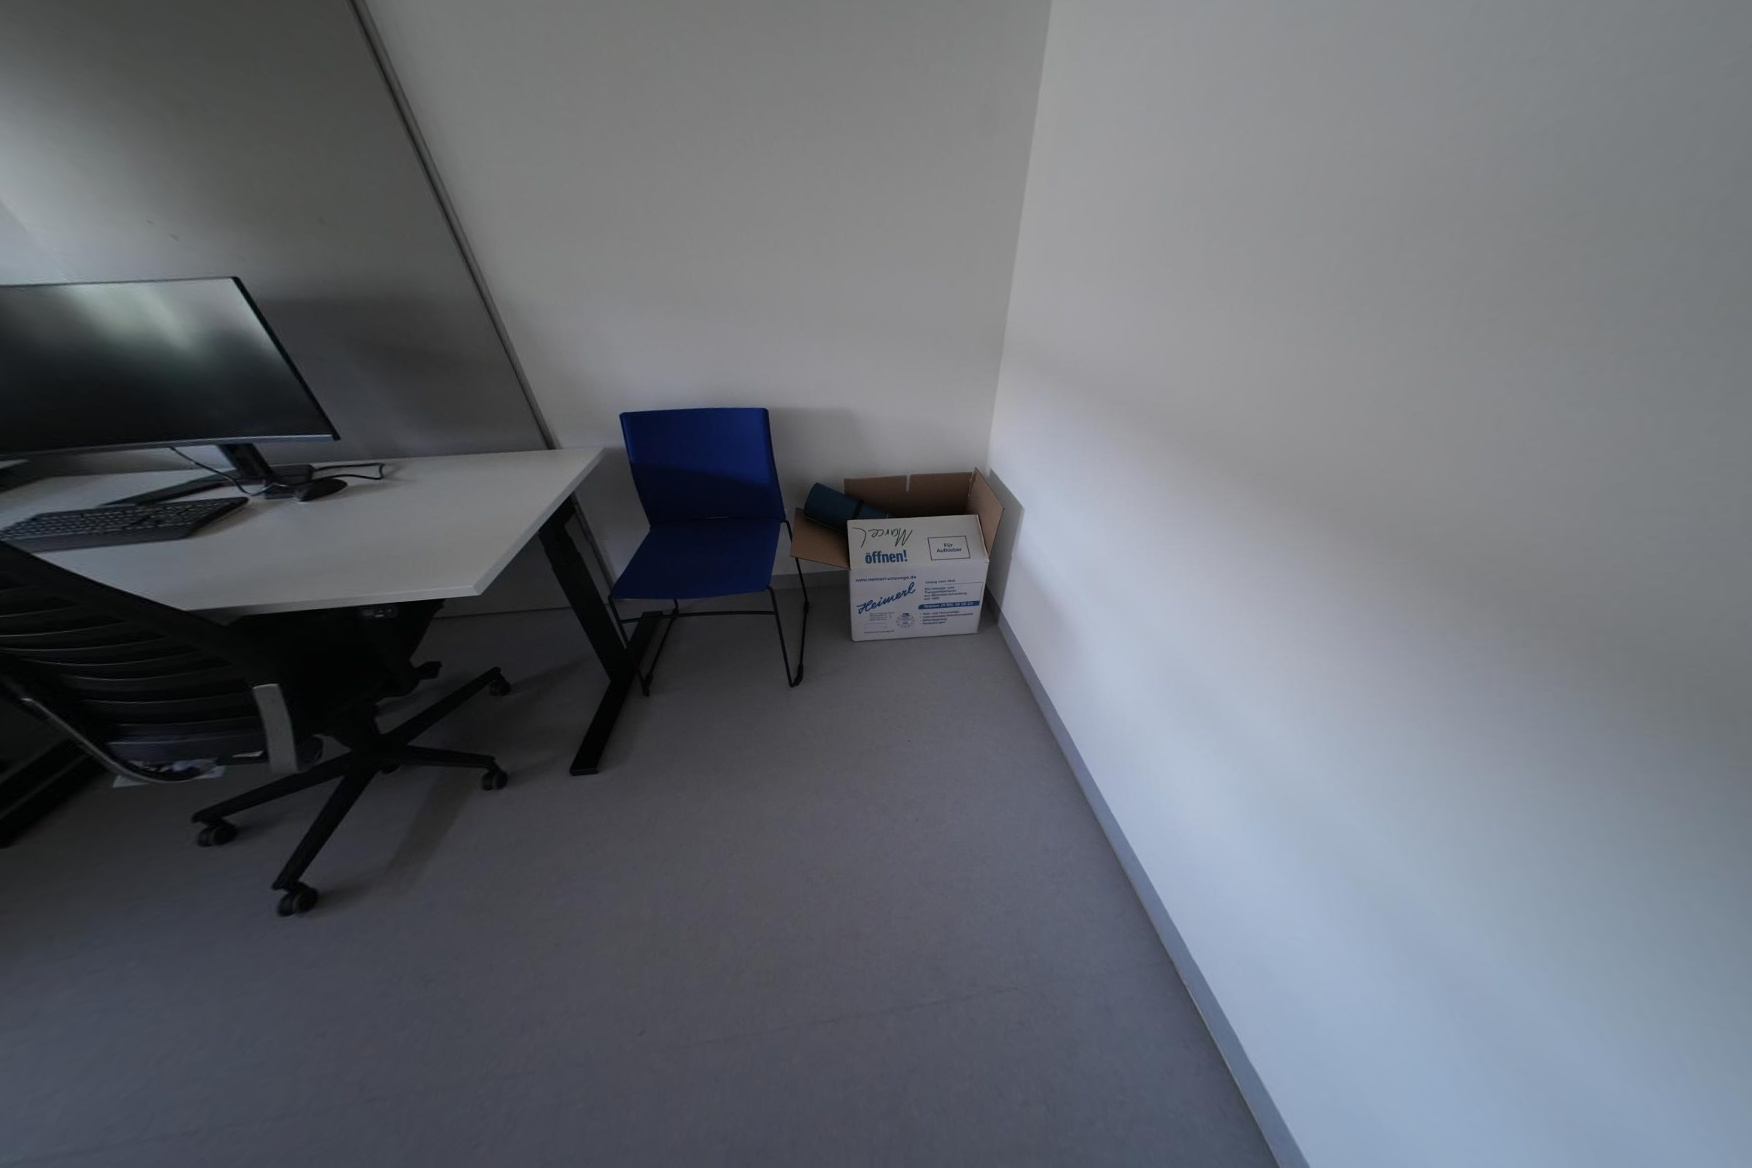
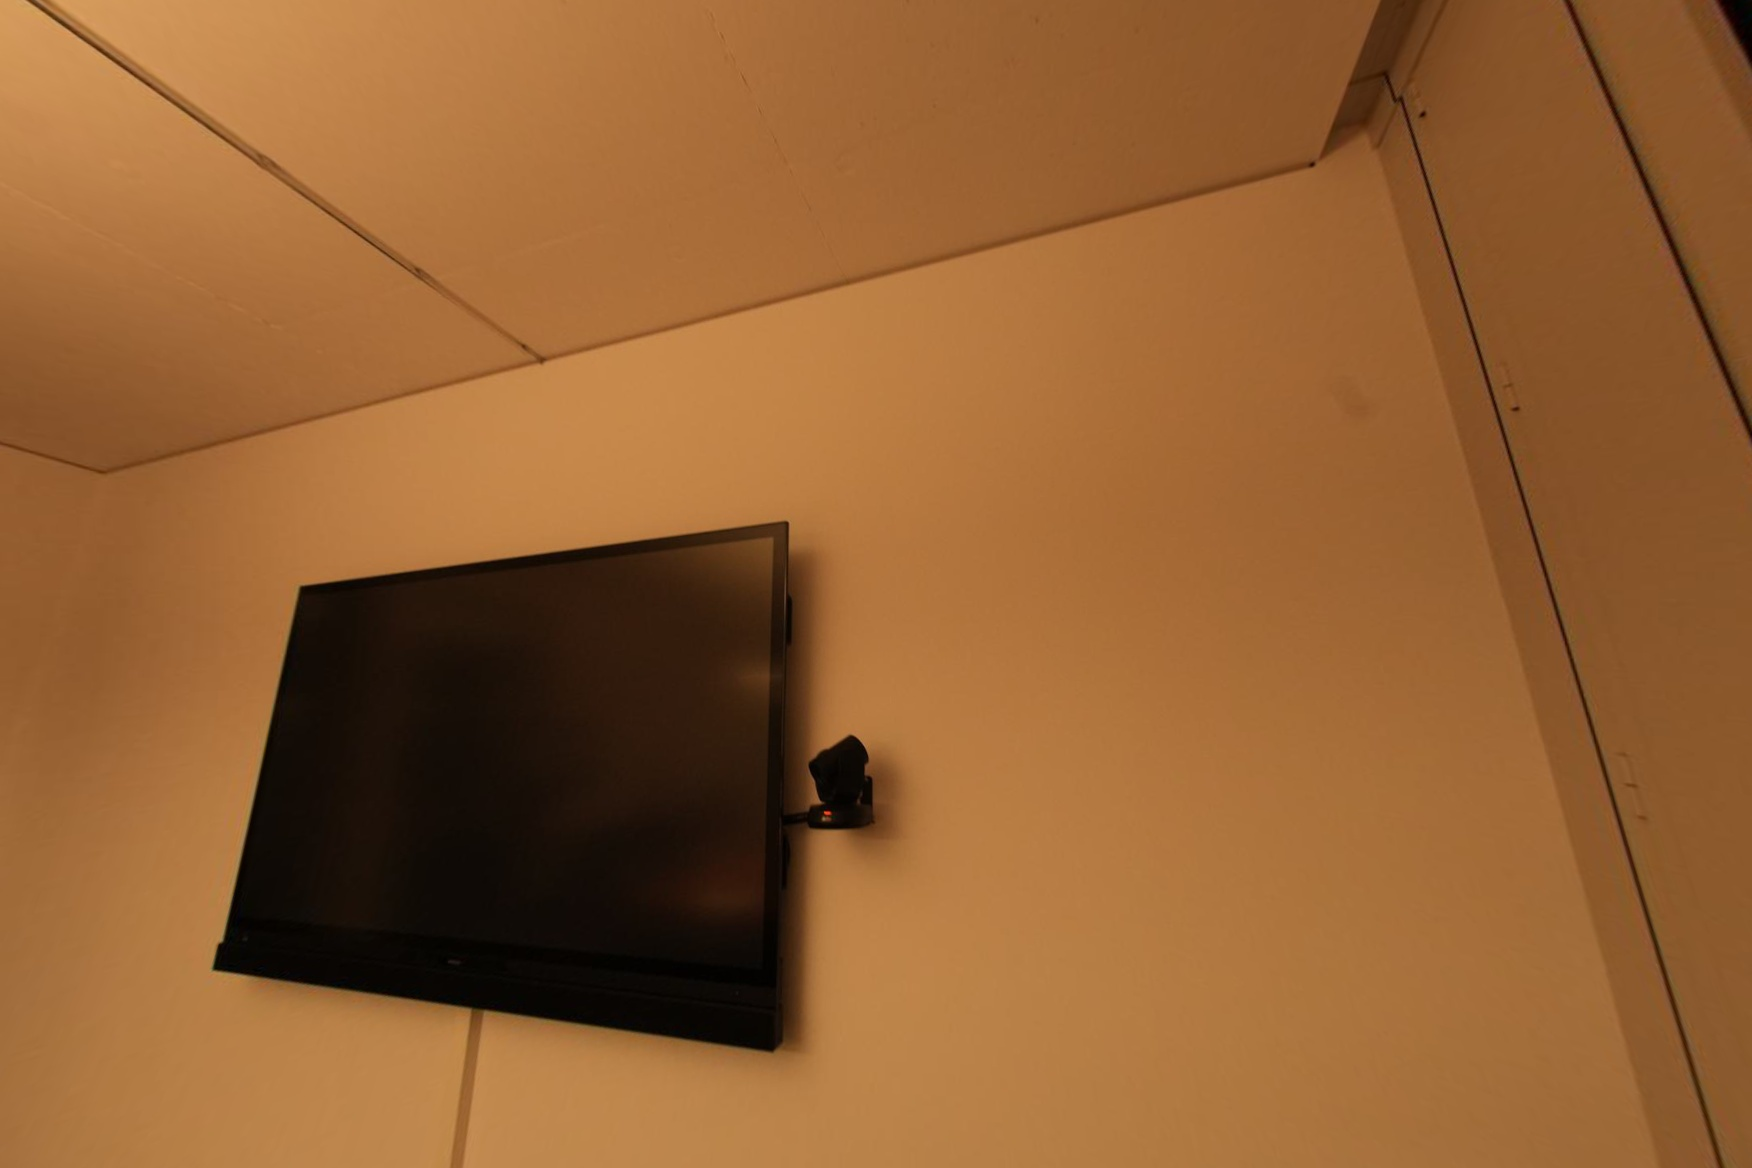
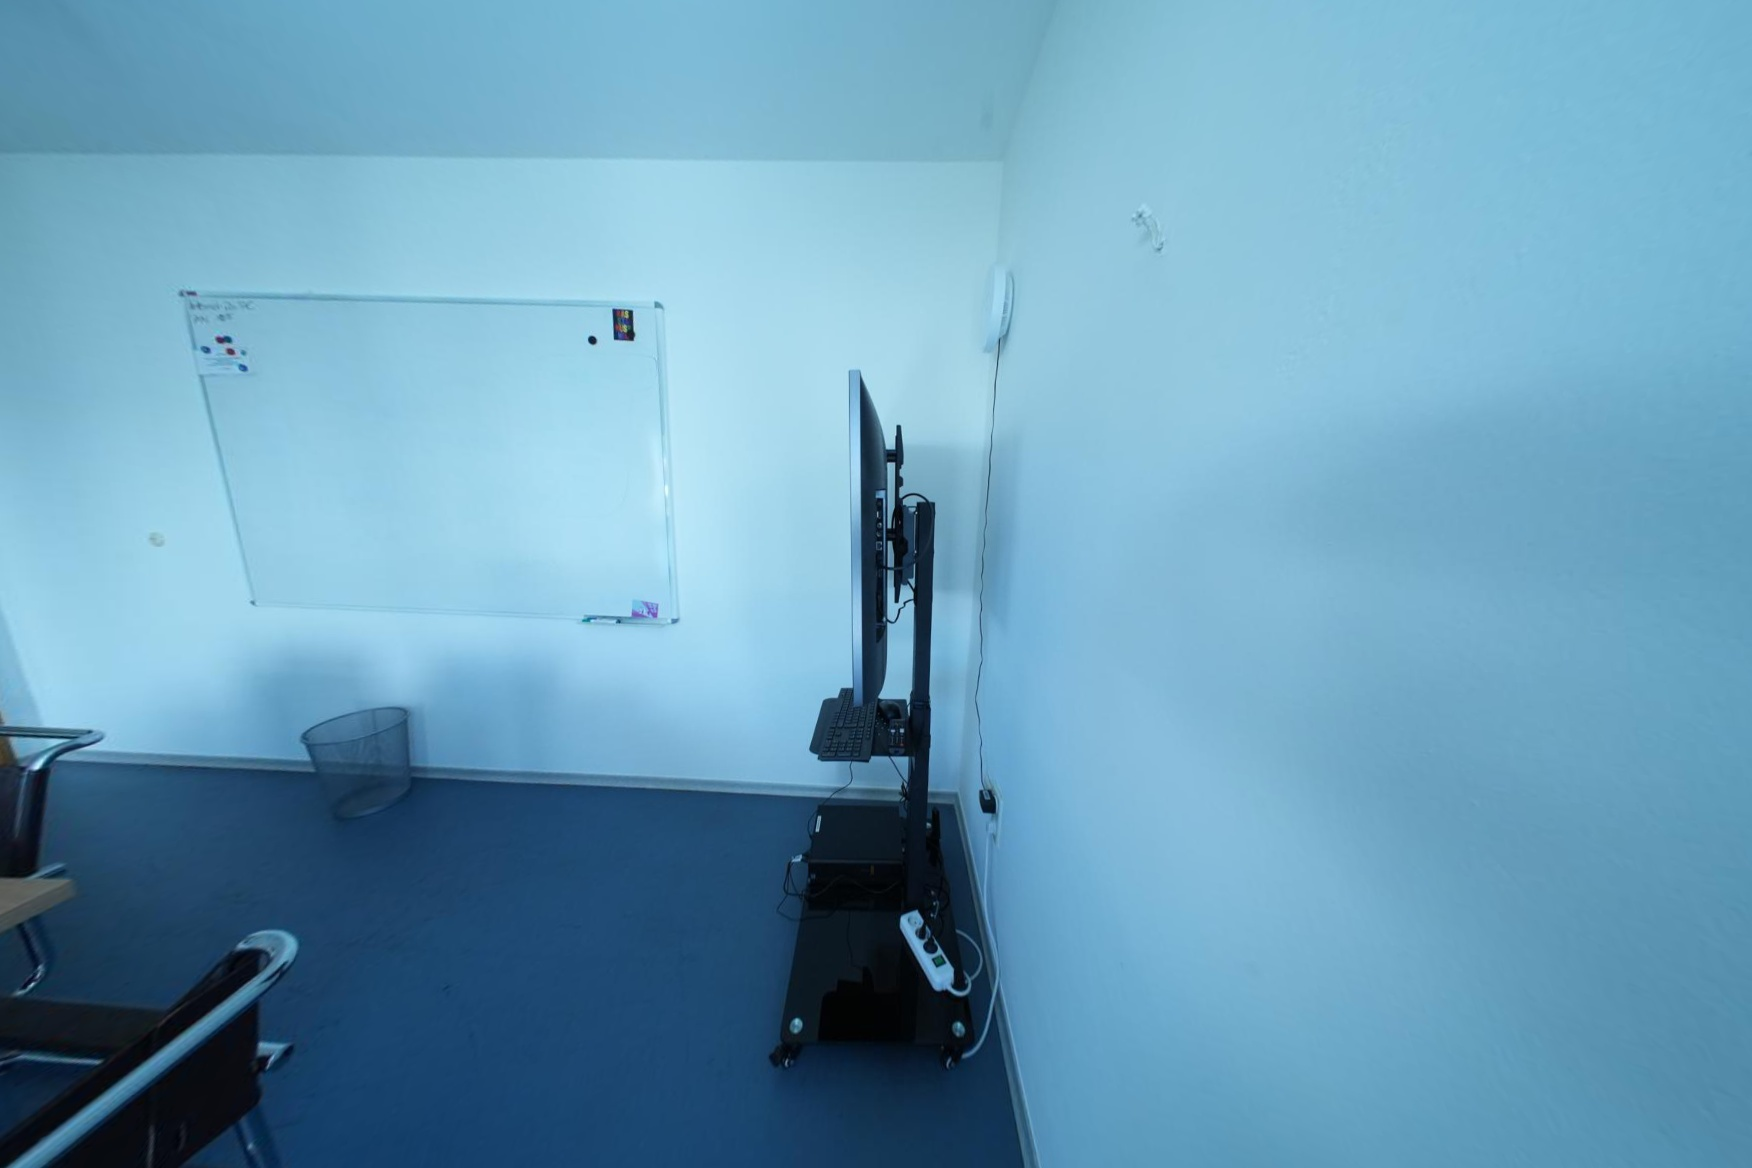
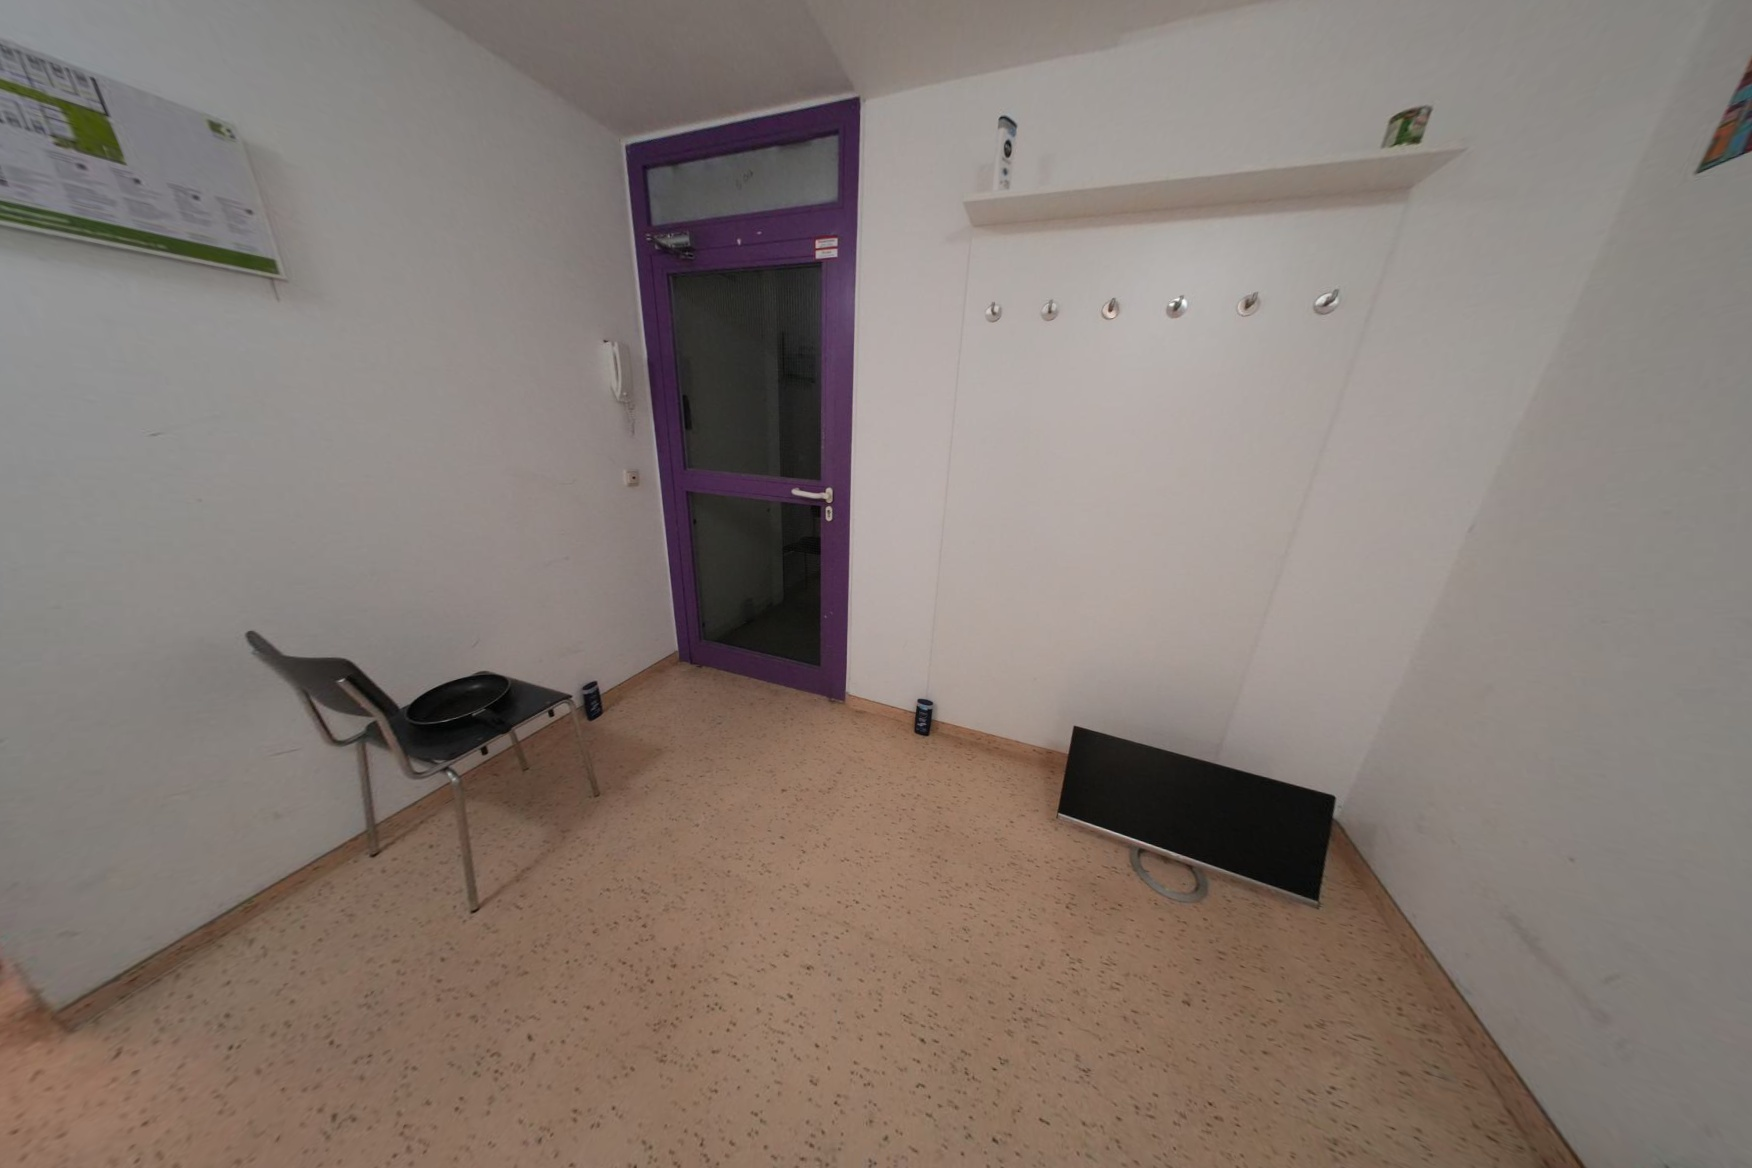

<IPython.core.display.Javascript object>

Use the checkboxes above. Then copy the Selected scene IDs text and paste it into Cell 5 (SELECTED_IDS_TEXT).


In [ ]:
import base64
import uuid
from IPython.display import HTML, Javascript, display

def resolve_image_path(path_value: str) -> Path | None:
    p = Path(path_value)
    candidates = [
        p,
        PROJECT_ROOT / p,
        PROJECT_ROOT.parent / p,
    ]
    for c in candidates:
        if c.exists():
            return c
    return None

def image_to_data_uri(path: Path) -> str:
    suffix = path.suffix.lower()
    mime = "image/jpeg" if suffix in {".jpg", ".jpeg"} else "image/png"
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:{mime};base64,{encoded}"

root_id = f"scene-selector-{uuid.uuid4().hex[:8]}"
cards = []

for i, row in enumerate(TOP_ROWS, start=1):
    scene_id = row["scene_id"]
    img_path = resolve_image_path(row["representative_image"])

    if img_path is None:
        img_html = "<div style='height:190px;display:flex;align-items:center;justify-content:center;background:#f6f6f6;color:#b00;'>Image not found</div>"
    else:
        src = image_to_data_uri(img_path)
        img_html = f"<img src='{src}' alt='scene {escape(scene_id)}'/>"

    cards.append(
        f"""
        <div class='card'>
          {img_html}
          <div class='cap'>
            <b>{i}. {escape(scene_id)}</b><br>
            type={escape(row['scene_type'])}<br>
            score={row['final_score']:.4f}, clutter={row['visual_clutter']:.4f}, open={row['open_ratio']:.4f}
          </div>
          <label class='pick'>
            <input type='checkbox' class='scene-check' data-scene-id='{escape(scene_id)}' /> Select
          </label>
        </div>
        """
    )

html = f"""
<style>
#{root_id} .toolbar {{ display:flex; flex-wrap:wrap; gap:8px; margin-bottom:10px; }}
#{root_id} .gallery {{ display:grid; grid-template-columns: repeat({max(1, N_COLS)}, minmax(220px, 1fr)); gap:14px; }}
#{root_id} .card {{ border:1px solid #ddd; border-radius:10px; overflow:hidden; background:#fff; box-shadow:0 1px 4px rgba(0,0,0,0.08); }}
#{root_id} .card img {{ width:100%; height:190px; object-fit:cover; display:block; background:#f6f6f6; }}
#{root_id} .cap {{ padding:10px; font-size:12px; line-height:1.35; }}
#{root_id} .pick {{ display:block; padding:0 10px 10px 10px; font-size:13px; }}
#{root_id} textarea {{ width:100%; min-height:52px; font-family:monospace; }}
</style>

<div id='{root_id}'>
  <div class='toolbar'>
    <button id='{root_id}-select-all'>Select all shown</button>
    <button id='{root_id}-clear'>Clear selection</button>
  </div>

  <div><b>Selected scene IDs (copy this into Cell 5: SELECTED_IDS_TEXT)</b></div>
  <textarea id='{root_id}-ids' readonly></textarea>
  <div class='toolbar'>
    <button id='{root_id}-copy-ids'>Copy IDs</button>
  </div>

  <div class='gallery'>
    {''.join(cards)}
  </div>
</div>
"""

display(HTML(html))

js = f"""
(function() {{
  const root = document.getElementById('{root_id}');
  if (!root) return;

  const checks = Array.from(root.querySelectorAll('input.scene-check'));
  const idsBox = root.querySelector('#{root_id}-ids');
  const selectAllBtn = root.querySelector('#{root_id}-select-all');
  const clearBtn = root.querySelector('#{root_id}-clear');
  const copyIdsBtn = root.querySelector('#{root_id}-copy-ids');

  function refresh() {{
    const picked = checks.filter(c => c.checked);
    idsBox.value = picked.map(c => c.dataset.sceneId).join(',');
  }}

  checks.forEach(c => c.addEventListener('change', refresh));
  selectAllBtn?.addEventListener('click', function() {{ checks.forEach(c => c.checked = true); refresh(); }});
  clearBtn?.addEventListener('click', function() {{ checks.forEach(c => c.checked = false); refresh(); }});
  copyIdsBtn?.addEventListener('click', function() {{
    if (navigator.clipboard && idsBox.value) navigator.clipboard.writeText(idsBox.value);
  }});

  refresh();
}})();
"""

display(Javascript(js))

print("Use the checkboxes above. Copy Selected scene IDs and paste into Cell 5 SELECTED_IDS_TEXT.")

In [ ]:
# Export selected scenes to outputs/ and package as tar.gz for transfer
import json
import shutil
import tarfile

# Paste comma-separated IDs copied from Cell 4 here, for example:
# "6126572846,d61691f945,46001f434d"
SELECTED_IDS_TEXT = ""

# full_scenes: copy each selected data/<scene_id>/ directory (can be large)
# representative_images_only: export only representative images + manifests
EXPORT_MODE = "full_scenes"  # options: full_scenes, representative_images_only
OVERWRITE_EXPORT = True

SELECTED_IDS = [s.strip() for s in SELECTED_IDS_TEXT.split(",") if s.strip()]
SELECTED_IDS = sorted(set(SELECTED_IDS))

EXPORT_ROOT = PROJECT_ROOT / "outputs" / "selected_scenes_export"
EXPORT_IMAGES_DIR = EXPORT_ROOT / "representative_images"
EXPORT_SCENES_DIR = EXPORT_ROOT / "scenes"
MANIFEST_CSV = EXPORT_ROOT / "selected_scene_candidates.csv"
MANIFEST_JSON = EXPORT_ROOT / "selected_scene_candidates.json"
ARCHIVE_PATH = PROJECT_ROOT / "outputs" / "selected_scenes_export.tar.gz"

selected_rows = [r for r in TOP_ROWS if r["scene_id"] in set(SELECTED_IDS)]

if not selected_rows:
    print("No scenes selected.")
    print("- In Cell 4, click scenes and copy IDs from the text box.")
    print("- Paste IDs into SELECTED_IDS_TEXT and rerun Cell 5.")
else:
    if OVERWRITE_EXPORT and EXPORT_ROOT.exists():
        shutil.rmtree(EXPORT_ROOT)

    EXPORT_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
    if EXPORT_MODE == "full_scenes":
        EXPORT_SCENES_DIR.mkdir(parents=True, exist_ok=True)

    missing_scene_dirs = []
    missing_images = []

    for row in selected_rows:
        scene_id = row["scene_id"]

        src_img = resolve_image_path(row["representative_image"])
        if src_img is None or not src_img.exists():
            missing_images.append(scene_id)
        else:
            dst_img = EXPORT_IMAGES_DIR / f"{scene_id}{src_img.suffix.lower()}"
            shutil.copy2(src_img, dst_img)

        if EXPORT_MODE == "full_scenes":
            src_scene_dir = PROJECT_ROOT / "data" / scene_id
            if not src_scene_dir.exists():
                missing_scene_dirs.append(scene_id)
            else:
                dst_scene_dir = EXPORT_SCENES_DIR / scene_id
                shutil.copytree(src_scene_dir, dst_scene_dir, dirs_exist_ok=True)

    fields = list(selected_rows[0].keys())
    with MANIFEST_CSV.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        writer.writerows(selected_rows)

    with MANIFEST_JSON.open("w", encoding="utf-8") as f:
        json.dump(selected_rows, f, indent=2)

    if ARCHIVE_PATH.exists():
        ARCHIVE_PATH.unlink()

    with tarfile.open(ARCHIVE_PATH, "w:gz") as tar:
        tar.add(EXPORT_ROOT, arcname=EXPORT_ROOT.name)

    print(f"Selected scenes     : {len(selected_rows)}")
    print(f"Export mode         : {EXPORT_MODE}")
    print(f"Export folder       : {EXPORT_ROOT}")
    print(f"Tar.gz archive      : {ARCHIVE_PATH}")

    if missing_images:
        print(f"Missing rep images  : {len(missing_images)}")
    if missing_scene_dirs:
        print(f"Missing scene dirs  : {len(missing_scene_dirs)}")

    print("\nTransfer to another Linux machine:")
    print(f"scp {ARCHIVE_PATH} user@remote:/path/")
    print("Then extract on remote:")
    print(f"tar -xzf {ARCHIVE_PATH.name}")

Selected scenes     : 9
Export mode         : full_scenes
Export folder       : /mnt/hdd/Scannet++/4DHOI/outputs/selected_scenes_export
Tar.gz archive      : /mnt/hdd/Scannet++/4DHOI/outputs/selected_scenes_export.tar.gz

Transfer to another Linux machine:
scp /mnt/hdd/Scannet++/4DHOI/outputs/selected_scenes_export.tar.gz user@remote:/path/
Then extract on remote:
tar -xzf selected_scenes_export.tar.gz
